
🚑 Running model for 2025-07-06...
[info] Loaded directed compat: 94 allowed edges.
Solve time for 2025-07-06: 0.76 s | Obj: 2349.0
Unplaced admissions present.
Export complete: plan_day_2025-07-06.xlsx
✅ Model for 2025-07-06 completed.

🚑 Running model for 2025-07-07...
[info] Loaded directed compat: 94 allowed edges.
Solve time for 2025-07-07: 0.75 s | Obj: 3555.0
Unplaced admissions present.
Export complete: plan_day_2025-07-07.xlsx
✅ Model for 2025-07-07 completed.

🚑 Running model for 2025-07-08...
[info] Loaded directed compat: 94 allowed edges.
Solve time for 2025-07-08: 0.85 s | Obj: 3452.0
Unplaced admissions present.
Export complete: plan_day_2025-07-08.xlsx
✅ Model for 2025-07-08 completed.

🚑 Running model for 2025-07-09...
[info] Loaded directed compat: 94 allowed edges.
Solve time for 2025-07-09: 0.27 s | Obj: 2452.0
Unplaced admissions present.
Export complete: plan_day_2025-07-09.xlsx
✅ Model for 2025-07-09 completed.

🚑 Running model for 2025-07-10...
[info] Loaded dir

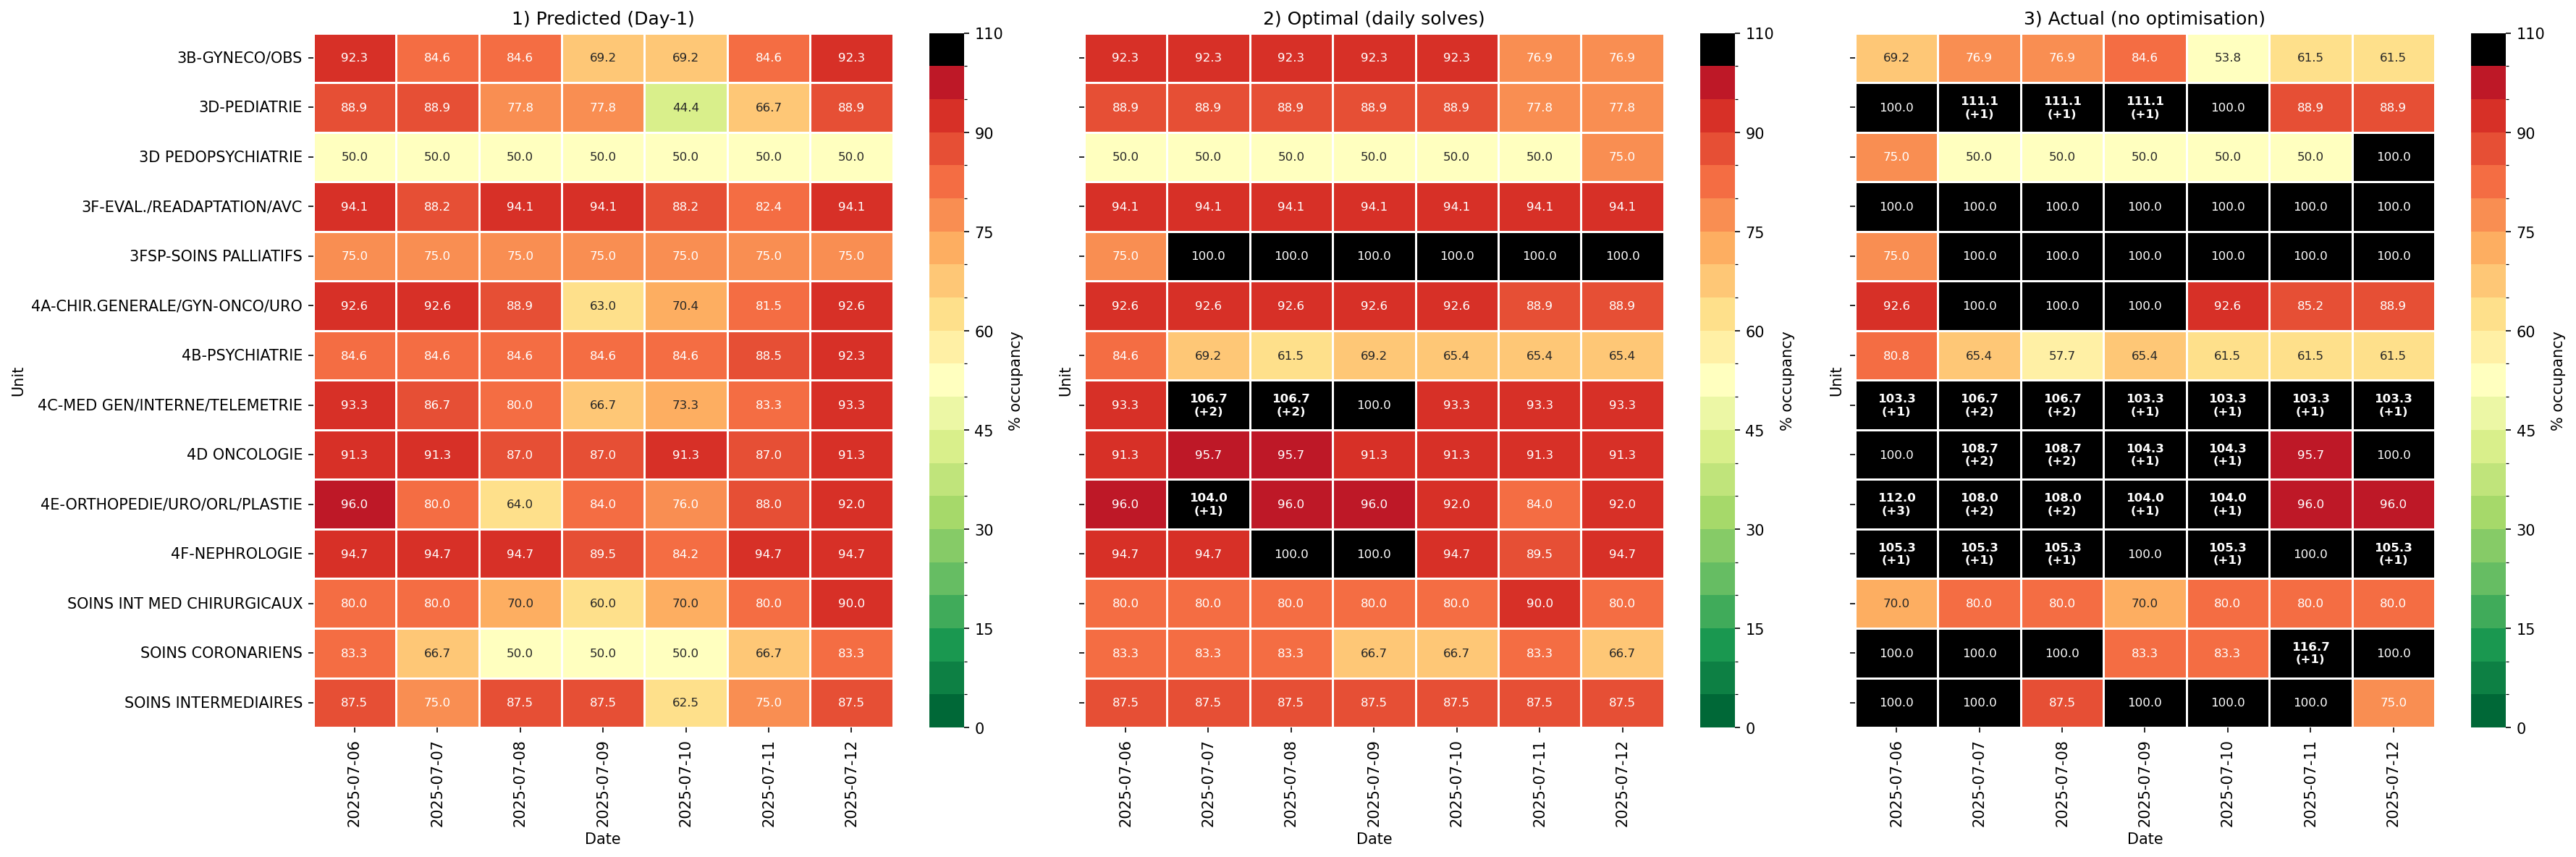

[ok] Comparison saved: compare_three_heatmaps_20250706_to_20250712.png


In [1]:
# ================================================================
# ILP BASELINE + 7-DAY HEATMAPS: Predicted vs Optimal vs Actual
# - Runs your ILP for a 7-day window starting ANCHOR_DATE
# - Saves per-day workbooks: plan_day_YYYY-MM-DD.xlsx
# - Ensures Day-1 workbook has HorizonOcc_Long and HorizonOcc sheets
# - Exports 3 heatmaps (CSV + PNG) and a comparison figure
# ================================================================

# --------------------- IMPORTS & CONFIG ---------------------
import os, glob, math, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date, datetime, timedelta
from matplotlib.colors import BoundaryNorm, ListedColormap

# ---- Window settings ----
ANCHOR_DATE     = "2025-07-06"                # Day-1
NUM_DAYS        = 7                           # 7-day horizon
INPUTS_FILE     = "hospital_model_inputs.xlsx"
BEDS_SHEET      = "beds"
FORECASTS_SHEET = "forecasts"
COMPAT_FILE     = "compatibility_matrix.xlsx"
COMPAT_SHEET    = "matrix"

# ---- File patterns for later aggregation ----
DAILY_PATTERN   = "plan_day_2025-07-*.xlsx"
CENSUS_PATTERN  = "raw_init_2025-07-*.csv"

# ---- Standard unit order ----
UNIT_ORDER = [
    '3B-GYNECO/OBS','3D-PEDIATRIE','3D PEDOPSYCHIATRIE','3F-EVAL./READAPTATION/AVC',
    '3FSP-SOINS PALLIATIFS','4A-CHIR.GENERALE/GYN-ONCO/URO','4B-PSYCHIATRIE',
    '4C-MED GEN/INTERNE/TELEMETRIE','4D ONCOLOGIE','4E-ORTHOPEDIE/URO/ORL/PLASTIE',
    '4F-NEPHROLOGIE','SOINS INT MED CHIRURGICAUX','SOINS CORONARIENS','SOINS INTERMEDIAIRES'
]

# ---------- COMPATIBILITY (EXCEL, DIRECTED) ----------
def load_compat_from_xlsx(xlsx_path, units, sheet_name="matrix"):
    """
    Load a directed compatibility matrix from Excel.
    Supports:
      A) WIDE matrix (rows=origin, cols=destination, 0/1)
      B) LONG list  (columns: Origin, Destination, Allowed)
    Returns:
      compat_df : DataFrame aligned to `units` (rows=units, cols=units, 0/1)
      ALLOWED   : set of directed edges (i,j) where compat_df.loc[i,j]==1 and i!=j
      compat    : dict {(i,j): 0/1}
    """
    import pandas as pd
    canon = lambda s: str(s).strip()

    units_c = [canon(u) for u in units]
    df_raw  = pd.read_excel(xlsx_path, sheet_name=sheet_name)

    # Detect LONG vs WIDE
    lower = {c.lower().strip(): c for c in df_raw.columns}
    has_long = {"origin","destination"} <= set(lower.keys())

    if has_long:
        # LONG format
        df = df_raw.rename(columns={
            lower["origin"]: "Origin",
            lower["destination"]: "Destination",
            (lower.get("allowed") or list(df_raw.columns)[-1]): "Allowed"
        })
        df["Origin"]      = df["Origin"].map(canon)
        df["Destination"] = df["Destination"].map(canon)
        df["Allowed"]     = pd.to_numeric(df["Allowed"], errors="coerce").fillna(0).astype(int)

        compat_df = pd.DataFrame(0, index=units_c, columns=units_c, dtype=int)
        for _, r in df.iterrows():
            o, d, v = r["Origin"], r["Destination"], int(r["Allowed"])
            if o in compat_df.index and d in compat_df.columns:
                compat_df.loc[o, d] = 1 if v != 0 else 0
    else:
        # WIDE format
        first_col = df_raw.columns[0]
        df = df_raw.copy()
        df[first_col] = df[first_col].map(canon)
        keep_cols = [first_col] + [c for c in df.columns[1:] if canon(c) in units_c]
        df = df[keep_cols].copy()
        ren = {c: canon(c) for c in df.columns}; ren[first_col] = "Origin"
        df = df.rename(columns=ren)
        for c in df.columns[1:]:
            df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0).astype(int)
        compat_df = (df.set_index("Origin")
                       .reindex(index=units_c, columns=units_c)
                       .fillna(0).astype(int))

    ALLOWED = {(i, j) for i in compat_df.index for j in compat_df.columns
               if i != j and int(compat_df.at[i, j]) == 1}
    compat  = {(i, j): int(compat_df.at[i, j])
               for i in compat_df.index for j in compat_df.columns}

    # Diagnostics
    missing_rows = [u for u in units_c if u not in compat_df.index]
    missing_cols = [u for u in units_c if u not in compat_df.columns]
    if missing_rows or missing_cols:
        print("[warn] Some units missing in compat file -> treated as 0:")
        if missing_rows: print("  missing rows:", missing_rows)
        if missing_cols: print("  missing cols:", missing_cols)
    print(f"[info] Loaded directed compat: {len(ALLOWED)} allowed edges.")
    return compat_df, ALLOWED, compat

# ----------------- COLOR / PLOTTING HELPERS -----------------
def red_to_black_norm_cmap():
    """
    RdYlGn_r for 0..100% (bins every 5%), >100% shown in black.
    Returns (norm, cmap) in this order.
    """
    bounds = list(range(0, 101, 5)) + [110]
    base = plt.colormaps["RdYlGn_r"].resampled(len(bounds)-1)
    colors = [base(i) for i in range(base.N)] + ["black"]
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(bounds, cmap.N)
    return norm, cmap

def ensure_unit_date_order(pivot, units, labels):
    """
    Keep only present units, enforce unit and date order, drop empty rows/cols, round to 1 decimal.
    """
    present_units = [u for u in units if u in pivot.index]
    pivot = pivot.reindex(index=present_units, columns=labels)
    pivot = pivot.drop(index=pivot.index[pivot.isna().all(axis=1)],
                       columns=pivot.columns[pivot.isna().all(axis=0)])
    if pivot.size == 0:
        raise ValueError("Empty pivot after alignment. Check source files and column names.")
    return pivot.round(1)

def save_matrix_and_heatmap(df, title, out_stem):
    """
    Save a CSV and a PNG heatmap with consistent formatting (annotated values).
    df: DataFrame with index as units (subset of UNIT_ORDER) and ISO date columns.
    """
    df = df.reindex(index=[u for u in UNIT_ORDER if u in df.index])
    df.columns = [str(c) for c in df.columns]

    csv_path = f"{out_stem}.csv"
    df.to_csv(csv_path, index=True)

    norm, cmap = red_to_black_norm_cmap()
    plt.figure(figsize=(14, 8), dpi=150)
    ax = sns.heatmap(
        df, cmap=cmap, norm=norm,
        linewidths=.5, linecolor='white',
        cbar_kws={"label": "% occupancy"},
        vmin=0, vmax=101,
        annot=True, fmt=".1f", annot_kws={"size": 8}
    )
    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Unit")

    # Contrast for >100% (black bin)
    texts = ax.texts
    vals = df.to_numpy()
    if vals.size:
        nrows, ncols = vals.shape
        for i in range(nrows):
            for j in range(ncols):
                v = vals[i, j]
                if pd.notna(v) and v > 100:
                    idx = i * ncols + j
                    if idx < len(texts):
                        texts[idx].set_color("white")
                        texts[idx].set_fontweight("bold")

    png_path = f"{out_stem}.png"
    plt.tight_layout()
    plt.savefig(png_path, bbox_inches="tight")
    plt.close()
    return csv_path, png_path


# ===== Overflow-aware annotations=====
def _labels_and_overflow_counts(occ_df: pd.DataFrame, beds_s: pd.Series):
    """
    occ_df: % occupancy (including overflow), index=Unit, columns=ISO dates
    beds_s: Series of staffed beds per unit (index=Unit)
    Returns:
      labels_df   : string annotations like "104.0\n(+3)" only when overflow>0
      overflow_df : integer overflow counts per cell
    """
    B = beds_s.reindex(occ_df.index).astype(float)
    Bmat = np.tile(B.to_numpy().reshape(-1, 1), occ_df.shape[1])

    occ = occ_df.astype(float).to_numpy()          # % values
    headcount = np.rint(occ / 100.0 * Bmat)        # ~patients
    overflow  = np.maximum(0, headcount - Bmat).astype(int)

    overflow_df = pd.DataFrame(overflow, index=occ_df.index, columns=occ_df.columns)

    labels_df = occ_df.round(1).astype(str)
    for i in range(occ_df.shape[0]):
        for j in range(occ_df.shape[1]):
            k = overflow_df.iat[i, j]
            if k > 0:
                labels_df.iat[i, j] = f"{labels_df.iat[i, j]}\n(+{k})"
    return labels_df, overflow_df


def save_matrix_and_heatmap_with_overflow(df, beds_s, title, out_stem, norm, cmap):
    """
    Drop-in replacement for saving a heatmap:
      - Saves the % matrix as <out_stem>.csv
      - Saves overflow counts as <out_stem>_overflow_counts.csv
      - Plots % values and annotates '+k' where overflow>0
    """
    df = df.reindex(index=[u for u in UNIT_ORDER if u in df.index])
    df.columns = [str(c) for c in df.columns]

    csv_pct = f"{out_stem}.csv"
    df.to_csv(csv_pct, index=True)

    labels_df, overflow_df = _labels_and_overflow_counts(df, beds_s)
    csv_ovf = f"{out_stem}_overflow_counts.csv"
    overflow_df.to_csv(csv_ovf, index=True)

    plt.figure(figsize=(14, 8), dpi=150)
    ax = sns.heatmap(
        df, cmap=cmap, norm=norm,
        vmin=0, vmax=101,
        linewidths=.5, linecolor='white',
        cbar_kws={"label": "% occupancy"},
        annot=labels_df, fmt="", annot_kws={"size": 8}
    )
    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Unit")

    # make annotation text readable on >100% (black bin)
    vals = df.to_numpy()
    nrows, ncols = vals.shape
    for i in range(nrows):
        for j in range(ncols):
            if pd.notna(vals[i, j]) and vals[i, j] > 100:
                idx = i * ncols + j
                if idx < len(ax.texts):
                    ax.texts[idx].set_color("white")
                    ax.texts[idx].set_fontweight("bold")

    png_path = f"{out_stem}.png"
    plt.tight_layout()
    plt.savefig(png_path, bbox_inches="tight")
    plt.close()

    return csv_pct, csv_ovf, png_path




# --------------------- YOUR ILP MODEL -----------------------
def run_day_model(input_file=INPUTS_FILE, plan_date=None):
    """
    Runs the ILP for a single 'plan_date' and writes plan_day_YYYY-MM-DD.xlsx
    Also embeds a Heatmap image AND writes HorizonOcc_Long & HorizonOcc sheets
    so we can reconstruct the predicted (7-day) matrix from Day-1.
    """
    from pulp import LpProblem, LpVariable, LpMinimize, lpSum, LpInteger, LpStatus, PULP_CBC_CMD

    if plan_date is None:
        plan_date = date.today().strftime("%Y-%m-%d")

    census_file = f"raw_init_{plan_date}.csv"
    if not os.path.exists(census_file):
        raise FileNotFoundError(f"Missing census file for {plan_date}: {census_file}")

    # Horizon length (match the 7-day window)
    T = NUM_DAYS

    # Canonical unit names
    canon = lambda s: str(s).strip()
    locations = [canon(u) for u in UNIT_ORDER]

    # ---- Load inputs ----
    df_init = pd.read_csv(census_file)
    df_raw  = pd.read_csv(census_file)
    df_for  = pd.read_excel(input_file, FORECASTS_SHEET)
    df_beds = pd.read_excel(input_file, BEDS_SHEET)

    # Canonicalize names in dictionaries
    raw_init         = dict(zip(df_init.Unit.map(canon), df_init.Raw_Census))
    admit_avg        = dict(zip(df_for.Unit.map(canon),  df_for.Admit_Avg))
    disch_avg_direct = dict(zip(df_for.Unit.map(canon),  df_for.Disch_Avg))
    los_avg          = dict(zip(df_for.Unit.map(canon),  df_for.Avg_LOS))
    beds             = dict(zip(df_beds.Unit.map(canon), df_beds.Beds))

    # Directed compatibility from Excel (no symmetry assumed)
    compat_df, ALLOWED, compat = load_compat_from_xlsx(COMPAT_FILE, locations, sheet_name=COMPAT_SHEET)

    # ---- Discharge estimate ----
    disch_combined = {}
    for u in admit_avg:
        est_by_los   = admit_avg[u] / los_avg[u] if los_avg[u] > 0 else 0
        est_by_direct= disch_avg_direct.get(u, est_by_los)
        disch_combined[u] = 0.5 * est_by_los + 0.5 * est_by_direct
    disch_int = {u: math.floor(disch_combined[u]) for u in disch_combined}

    # ---- Build ILP ----
    m = LpProblem("rolling_beds_backlog", LpMinimize)

    x     = LpVariable.dicts("Occ",          [(u,t) for u in locations for t in range(T+1)], 0, None, LpInteger)
    adm   = LpVariable.dicts("AdmitOK",      [(u,t) for u in locations for t in range(1, T+1)], 0, None, LpInteger)
    ad_of = LpVariable.dicts("AdOverflow",   [(u,t) for u in locations for t in range(1, T+1)], 0, None, LpInteger)
    st_of = LpVariable.dicts("StayOverflow", [(u,t) for u in locations for t in range(0, T+1)], 0, None, LpInteger)
    in85  = LpVariable.dicts("In85",         [(u,t) for u in locations for t in range(1, T+1)], 0, None, LpInteger)
    ov85  = LpVariable.dicts("Ov85",         [(u,t) for u in locations for t in range(1, T+1)], 0, None, LpInteger)

    # Transfers ONLY on allowed directed edges
    r    = LpVariable.dicts("Transfer",        [(i,j,t) for (i,j) in ALLOWED for t in range(1, T+1)], 0, None, LpInteger)
    r_bl = LpVariable.dicts("BacklogTransfer", [(i,j)   for (i,j) in ALLOWED], 0, None, LpInteger)

    # ---------- Helper sums (respect directed edges) ----------
    inbound  = lambda u, t: lpSum(r[v, u, t] for v in locations if (v, u) in ALLOWED)
    outbound = lambda u, t: lpSum(r[u, v, t] for v in locations if (u, v) in ALLOWED)
    bkin     = lambda u:    lpSum(r_bl[v, u]  for v in locations if (v, u) in ALLOWED)
    bkout    = lambda u:    lpSum(r_bl[u, v]  for v in locations if (u, v) in ALLOWED)

    # ---------- Objective ----------
    m += (
        lpSum(r_bl[i, j]           for (i, j) in ALLOWED) +
        lpSum(r[i, j, t]           for (i, j) in ALLOWED for t in range(1, T+1)) +
        100 * lpSum(ad_of[u, t]    for u in locations     for t in range(1, T+1)) +
        100 * lpSum(st_of[u, t]    for u in locations     for t in range(0, T+1))
    )

    # ---------- Initial conditions ----------
    for u in locations:
        m += x[u, 0] == raw_init.get(u, 0), f"InitOcc_{u}"
        m += st_of[u, 0] >= x[u, 0] - beds[u], f"InitOverflow_{u}"
        m += bkout(u) <= st_of[u, 0], f"BacklogCap_{u}"

    # ---------- Dynamics + caps ----------
    IDEAL_THRESHOLD = 0.85
    MAX_THRESHOLD   = 0.95

    for u in locations:
        for t in range(1, T+1):
            if t == 1:
                m += (
                    x[u, 1] == x[u, 0]
                               - bkout(u) + bkin(u)
                               + adm[u, 1] - disch_int[u]
                               + inbound(u, 1) - outbound(u, 1)
                ), f"Census1_{u}"
            else:
                m += (
                    x[u, t] == x[u, t-1]
                               + adm[u, t] - disch_int[u]
                               + inbound(u, t) - outbound(u, t)
                ), f"Census_{u}_{t}"

            # Decomposition + threshold rules
            m += x[u, t] == in85[u, t] + ov85[u, t] + st_of[u, t], f"Decomp_{u}_{t}"
            m += in85[u, t] <= int(IDEAL_THRESHOLD * beds[u]), f"Rule1_{u}_{t}"
            m += ov85[u, t] <= int(MAX_THRESHOLD * beds[u]) - int(IDEAL_THRESHOLD * beds[u]), f"Rule3_{u}_{t}"
            m += st_of[u, t] >= x[u, t] - int(MAX_THRESHOLD * beds[u]), f"Rule4_{u}_{t}"
            m += x[u, t] <= int(MAX_THRESHOLD * beds[u]) + st_of[u, t], f"Cap_{u}_{t}"

            # PlaceAll: only allowed outbound edges
            m += (
                adm[u, t] + outbound(u, t) + ad_of[u, t] == math.ceil(admit_avg[u])
            ), f"PlaceAll_{u}_{t}"

            # Receiver headroom: only for allowed (u -> v)
            for v in locations:
                if (u, v) in ALLOWED:
                    m += r[u, v, t] <= int(0.95 * beds[v]) - in85[v, t], f"Transfer_{u}_{v}_{t}"

    # Solve
    from time import time
    start = time()
    m.solve(PULP_CBC_CMD(msg=True))
    end = time()
    print(f"Solve time for {plan_date}: {round(end - start, 2)} s | Obj:", m.objective.value())

    # Unplaced admissions
    if LpStatus[m.status] != "Optimal":
        print("Solver did not find an optimal solution.")
        unplaced = []
    else:
        unplaced = [
            {"Unit": u, "Day": t, "Unplaced_Admissions": int(val)}
            for u in locations for t in range(1, T+1)
            if (val := ad_of[u, t].value()) is not None and val > 0
        ]
        print("Unplaced admissions present." if unplaced else "All admissions placed successfully.")

    # Beds used (Day 1) for the “optimal daily” aggregation
    beds_used = pd.DataFrame([{"Unit": u, "Beds_Used": x[u, 1].value(), "Beds": beds[u]} for u in locations])
    beds_used["Occupancy%"] = beds_used.Beds_Used / beds_used.Beds * 100

    # Transfers (Day 1) on allowed edges only
    new_trans = [
        {"Origin": i, "Destination": j, "Patients": int(r[i, j, 1].value())}
        for (i, j) in ALLOWED
        if r[i, j, 1].value() is not None and r[i, j, 1].value() > 0
    ]
    back_trans = [
        {"Origin": i, "Destination": j, "Patients": int(r_bl[i, j].value())}
        for (i, j) in ALLOWED
        if r_bl[i, j].value() is not None and r_bl[i, j].value() > 0
    ]

    # Overflows (admission + stay)
    if unplaced:
        df_unplaced = pd.DataFrame(unplaced)
    else:
        df_unplaced = pd.DataFrame(columns=["Unit", "Day", "Unplaced_Admissions"])

    stay_overflows = []
    for u in locations:
        for t in range(1, T + 1):
            val = st_of[u, t].value()
            if val is not None and val > 0:
                stay_overflows.append({"Unit": u, "Day": t, "Stay_Overflow": int(val)})
    df_stay_overflow = pd.DataFrame(stay_overflows) if stay_overflows else pd.DataFrame(columns=["Unit","Day","Stay_Overflow"])

    # ---- Build full 7-day horizon occupancy (% of beds) for Predicted sheets ----
    start_dt = datetime.strptime(plan_date, "%Y-%m-%d")
    horizon_recs = []
    for u in locations:
        for t in range(1, T + 1):
            occ_val = x[u, t].value()
            bed_val = beds[u]
            if occ_val is not None and bed_val:
                occ_pct = (occ_val / bed_val) * 100
                horizon_recs.append({
                    "Unit": u,
                    "Date": (start_dt + pd.Timedelta(days=t - 1)).strftime("%Y-%m-%d"),
                    "Occupancy%": round(occ_pct, 1)
                })
    df_horizon_long = pd.DataFrame(horizon_recs)
    if not df_horizon_long.empty:
        horizon_long = df_horizon_long[["Unit","Date","Occupancy%"]].copy()
        horizon_wide = horizon_long.pivot(index="Unit", columns="Date", values="Occupancy%").reindex(index=UNIT_ORDER)
    else:
        horizon_long = pd.DataFrame(columns=["Unit","Date","Occupancy%"])
        horizon_wide = pd.DataFrame(index=UNIT_ORDER)

    # ---- Write workbook ----
    file_name = f"plan_day_{plan_date}.xlsx"
    with pd.ExcelWriter(file_name) as writer:
        beds_used.to_excel(writer, sheet_name="Day1_Beds", index=False)
        pd.DataFrame(new_trans).to_excel(writer, sheet_name="NewTransfers", index=False)
        pd.DataFrame(back_trans).to_excel(writer, sheet_name="BacklogTransfers", index=False)
        df_unplaced.to_excel(writer, sheet_name="AdmissionOverflows", index=False)
        df_stay_overflow.to_excel(writer, sheet_name="StayOverflows", index=False)
        horizon_long.to_excel(writer, sheet_name="HorizonOcc_Long", index=False)
        horizon_wide.to_excel(writer, sheet_name="HorizonOcc")

    # ---- Also drop in a PNG heatmap for convenience (not used later) ----
    if not df_horizon_long.empty:
        pivot_occ = horizon_wide.copy()
        plt.figure(figsize=(14, 7))
        sns.heatmap(pivot_occ, annot=True, fmt=".1f", cmap="RdYlGn_r",
                    cbar_kws={'label': 'Occupancy %'}, linewidths=0.5)
        plt.title(f"Bed Occupancy Heatmap ({start_dt.strftime('%b %d')} onward)")
        plt.xlabel("Date")
        plt.ylabel("Unit")
        plt.tight_layout()
        heatmap_file = f"bed_occupancy_heatmap_{plan_date}.png"
        plt.savefig(heatmap_file, dpi=150)
        plt.close()

        from openpyxl import load_workbook
        from openpyxl.drawing.image import Image as XLImage
        wb = load_workbook(file_name)
        ws = wb.create_sheet("Heatmap")
        img = XLImage(heatmap_file)
        img.anchor = "A1"
        ws.add_image(img)
        wb.save(file_name)

    print(f"Export complete: {file_name}")
    return {"beds_used": beds_used, "raw_init_df": df_raw}

# --------------------- RUN 7 DAYS ---------------------
start_date = datetime.strptime(ANCHOR_DATE, "%Y-%m-%d")
dates = [start_date + timedelta(days=i) for i in range(NUM_DAYS)]
for d in dates:
    ds = d.strftime("%Y-%m-%d")
    print(f"\n🚑 Running model for {ds}...")
    try:
        _ = run_day_model(INPUTS_FILE, plan_date=ds)
        print(f"✅ Model for {ds} completed.")
    except FileNotFoundError as e:
        print(f"⚠️ Skipping {ds}: {e}")


## SCENARIO RUNS COMPARISON
# =========================

# ---------- Overflow-aware helpers (local to this section) ----------
def _labels_and_overflow_counts(occ_df: pd.DataFrame, beds_s: pd.Series):
    """
    occ_df: % occupancy (including overflow), index=Unit, columns=ISO dates
    beds_s: Series of staffed beds per unit (index=Unit)
    Returns:
      labels_df   : string annotations like "104.0\n(+3)" only when overflow>0
      overflow_df : integer overflow counts per cell
    """
    B = beds_s.reindex(occ_df.index).astype(float)
    # repeat each unit's bed count across all columns (days)
    Bmat = np.tile(B.to_numpy().reshape(-1, 1), occ_df.shape[1])

    occ = occ_df.astype(float).to_numpy()         # % values
    headcount = np.rint(occ / 100.0 * Bmat)       # approximate patients
    overflow  = np.maximum(0, headcount - Bmat).astype(int)

    overflow_df = pd.DataFrame(overflow, index=occ_df.index, columns=occ_df.columns)

    labels_df = occ_df.round(1).astype(str)
    for i in range(occ_df.shape[0]):
        for j in range(occ_df.shape[1]):
            k = overflow_df.iat[i, j]
            if k > 0:
                labels_df.iat[i, j] = f"{labels_df.iat[i, j]}\n(+{k})"
    return labels_df, overflow_df


def save_matrix_and_heatmap_with_overflow(df, beds_s, title, out_stem, norm, cmap):
    """
    Saves:
      - <out_stem>.csv              (percentages matrix)
      - <out_stem>_overflow_counts.csv (integer overflow headcounts)
      - <out_stem>.png              (heatmap with '+k' labels on overflow cells)
    """
    # row order + string columns like your other plots
    df = df.reindex(index=[u for u in UNIT_ORDER if u in df.index])
    df.columns = [str(c) for c in df.columns]

    # main CSV (percentages)
    csv_pct = f"{out_stem}.csv"
    df.to_csv(csv_pct, index=True)

    # labels & overflow counts
    labels_df, overflow_df = _labels_and_overflow_counts(df, beds_s)
    csv_ovf = f"{out_stem}_overflow_counts.csv"
    overflow_df.to_csv(csv_ovf, index=True)

    # plot with annotated overflow
    plt.figure(figsize=(14, 8), dpi=150)
    ax = sns.heatmap(
        df, cmap=cmap, norm=norm,
        vmin=0, vmax=101,
        linewidths=.5, linecolor='white',
        cbar_kws={"label": "% occupancy"},
        annot=labels_df, fmt="", annot_kws={"size": 8}
    )
    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Unit")

    # make annotation text readable on very dark cells (>100%) -> white + bold
    vals = df.to_numpy()
    nrows, ncols = vals.shape
    for i in range(nrows):
        for j in range(ncols):
            if pd.notna(vals[i, j]) and vals[i, j] > 100:
                idx = i * ncols + j
                if idx < len(ax.texts):
                    ax.texts[idx].set_color("white")
                    ax.texts[idx].set_fontweight("bold")

    png_path = f"{out_stem}.png"
    plt.tight_layout()
    plt.savefig(png_path, bbox_inches="tight")
    plt.close()

    return csv_pct, csv_ovf, png_path


# ----------------- SCENARIO 1: PREDICTED (Day-1) -----------------
def load_predicted_horizon(anchor_path, anchor_date, num_days=NUM_DAYS):
    """
    Build predicted 7-day occupancy matrix from the Day-1 workbook.
    Prefer 'HorizonOcc_Long'; fallback to 'HorizonOcc'.
    """
    if not os.path.exists(anchor_path):
        raise FileNotFoundError(f"Anchor workbook not found: {anchor_path}")
    xls = pd.ExcelFile(anchor_path)

    if "HorizonOcc_Long" in xls.sheet_names:
        dfH = pd.read_excel(anchor_path, "HorizonOcc_Long")[["Unit","Date","Occupancy%"]].copy()
        dfH["Date"] = pd.to_datetime(dfH["Date"]).dt.strftime("%Y-%m-%d")
        dates = sorted(dfH["Date"].unique())[:num_days]
        p = pd.pivot_table(
            dfH[dfH["Date"].isin(dates)],
            index="Unit", columns="Date", values="Occupancy%",
            aggfunc="mean", observed=False
        )
        p = ensure_unit_date_order(p, UNIT_ORDER, dates)
        return p

    if "HorizonOcc" in xls.sheet_names:
        wide = pd.read_excel(anchor_path, "HorizonOcc", index_col=0)
        cols = sorted([c for c in wide.columns])[:num_days]
        wide = wide[cols].copy()
        wide = ensure_unit_date_order(wide, UNIT_ORDER, cols)
        return wide

    raise ValueError(f"{anchor_path} has neither 'HorizonOcc_Long' nor 'HorizonOcc'.")

print("\n=== Scenario 1: Predicted (Day-1 horizon) ===")
anchor_file = f"plan_day_{ANCHOR_DATE}.xlsx"
df_pred = load_predicted_horizon(anchor_file, ANCHOR_DATE, NUM_DAYS)
pred_start, pred_end = df_pred.columns[0], df_pred.columns[-1]

# beds + colormap (build once, reuse across all 3 scenarios)
beds_series = pd.read_excel(INPUTS_FILE, sheet_name=BEDS_SHEET).set_index("Unit")["Beds"].astype(float)
norm, cmap = red_to_black_norm_cmap()

csv_pred, csv_pred_ovf, png_pred = save_matrix_and_heatmap_with_overflow(
    df_pred, beds_series,
    f"1) Predicted (solve once on {pd.to_datetime(ANCHOR_DATE).strftime('%b %d')})",
    f"predicted_occupancy_{pred_start}_to_{pred_end}",
    norm, cmap
)
print(f"[ok] Predicted saved: {csv_pred}, {csv_pred_ovf}, {png_pred}")


# ----------------- SCENARIO 2: OPTIMAL (daily solves) -----------------
print("\n=== Scenario 2: Optimal (daily solves) ===")
files = sorted(glob.glob(DAILY_PATTERN))[:NUM_DAYS]
if not files:
    raise FileNotFoundError(f"No files matched pattern: {DAILY_PATTERN}")

rows = []
for path in files:
    date_str = os.path.basename(path).split("_")[-1].split(".")[0]  # YYYY-MM-DD
    df = pd.read_excel(path, sheet_name="Day1_Beds")
    required = {"Unit", "Beds_Used", "Beds"}
    if not required.issubset(df.columns):
        missing = required - set(df.columns)
        raise ValueError(f"{path} missing columns: {missing}")
    df = df.copy()
    df["Beds_Used"] = pd.to_numeric(df["Beds_Used"], errors="coerce")
    df["Beds"]      = pd.to_numeric(df["Beds"], errors="coerce")
    df = df.dropna(subset=["Beds_Used","Beds"])
    df["Date"] = date_str
    df["Occupancy%"] = (df["Beds_Used"]/df["Beds"])*100
    rows.append(df[["Unit","Date","Occupancy%"]])

df_opt_all = pd.concat(rows, ignore_index=True)
labels_opt = sorted(df_opt_all["Date"].unique())[:NUM_DAYS]
p_opt = pd.pivot_table(
    df_opt_all[df_opt_all["Date"].isin(labels_opt)],
    index="Unit", columns="Date", values="Occupancy%",
    aggfunc="mean", observed=False
)
p_opt = ensure_unit_date_order(p_opt, UNIT_ORDER, labels_opt)

opt_start, opt_end = labels_opt[0], labels_opt[-1]
csv_opt, csv_opt_ovf, png_opt = save_matrix_and_heatmap_with_overflow(
    p_opt, beds_series,
    f"2) Optimal (daily solves) — {pd.to_datetime(opt_start).strftime('%b %d')} to {pd.to_datetime(opt_end).strftime('%b %d')}",
    f"optimal_results_{opt_start}_to_{opt_end}",
    norm, cmap
)
print(f"[ok] Optimal saved: {csv_opt}, {csv_opt_ovf}, {png_opt}")


# ----------------- SCENARIO 3: ACTUAL (raw census) -----------------
print("\n=== Scenario 3: Actual (no optimization) ===")
beds_df = pd.read_excel(INPUTS_FILE, sheet_name=BEDS_SHEET)[["Unit","Beds"]]
beds_df["Beds"] = pd.to_numeric(beds_df["Beds"], errors="coerce")
beds_df = beds_df.dropna(subset=["Beds"])

files_c = sorted(glob.glob(CENSUS_PATTERN))[:NUM_DAYS]
if not files_c:
    raise FileNotFoundError(f"No files matched pattern: {CENSUS_PATTERN}")

rows_c = []
for path in files_c:
    date_str = os.path.basename(path).split("_")[-1].split(".")[0]  # YYYY-MM-DD
    df = pd.read_csv(path)
    census_col = "Raw_Census" if "Raw_Census" in df.columns else ("Census" if "Census" in df.columns else None)
    if census_col is None or "Unit" not in df.columns:
        raise ValueError(f"{path} must have 'Unit' and 'Raw_Census' (or 'Census').")
    df = df[["Unit", census_col]].rename(columns={census_col: "Census"})
    df["Census"] = pd.to_numeric(df["Census"], errors="coerce")
    df = df.dropna(subset=["Census"])
    merged = df.merge(beds_df, on="Unit", how="left").dropna(subset=["Beds"])
    merged["Date"] = date_str
    merged["Occupancy%"] = (merged["Census"] / merged["Beds"]) * 100
    rows_c.append(merged[["Unit","Date","Occupancy%"]])

df_act_all = pd.concat(rows_c, ignore_index=True)
labels_act = sorted(df_act_all["Date"].unique())[:NUM_DAYS]
p_act = pd.pivot_table(
    df_act_all[df_act_all["Date"].isin(labels_act)],
    index="Unit", columns="Date", values="Occupancy%",
    aggfunc="mean", observed=False
)
p_act = ensure_unit_date_order(p_act, UNIT_ORDER, labels_act)

act_start, act_end = labels_act[0], labels_act[-1]
csv_act, csv_act_ovf, png_act = save_matrix_and_heatmap_with_overflow(
    p_act, beds_series,
    f"3) Actual (no optimization) — {pd.to_datetime(act_start).strftime('%b %d')} to {pd.to_datetime(act_end).strftime('%b %d')}",
    f"actual_occupancy_{act_start}_to_{act_end}",
    norm, cmap
)
print(f"[ok] Actual saved: {csv_act}, {csv_act_ovf}, {png_act}")


# ----------------- KPIs -----------------
def kpis(pivot):
    vals = pivot.to_numpy().astype(float)
    return np.nanmean(vals), np.sum(vals > 95), np.sum(vals > 100)

k1 = kpis(df_pred); k2 = kpis(p_opt); k3 = kpis(p_act)
print("\nKPI summary (mean occupancy %, #cells >95%, #cells >100%)")
print(f"  1) Predicted : mean={k1[0]:.1f}%, >95%={k1[1]}, >100%={k1[2]}")
print(f"  2) Optimal   : mean={k2[0]:.1f}%, >95%={k2[1]}, >100%={k2[2]}")
print(f"  3) Actual    : mean={k3[0]:.1f}%, >95%={k3[1]}, >100%={k3[2]}  (actual may include >100%)")


# ----------------- CSV-BASED SIDE-BY-SIDE COMPARISON -----------------
print("\n=== Comparison figure (CSV-based) ===")

# Paths to the matrices we just saved above (percentages CSVs)
cmp_pred_path = f"predicted_occupancy_{pred_start}_to_{pred_end}.csv"
cmp_opt_path  = f"optimal_results_{opt_start}_to_{opt_end}.csv"
cmp_act_path  = f"actual_occupancy_{act_start}_to_{act_end}.csv"

def load_matrix(path):
    """Load a heatmap matrix CSV and reindex to our canonical UNIT_ORDER."""
    df = pd.read_csv(path, index_col=0)
    return df.reindex(index=[u for u in UNIT_ORDER if u in df.index])

# Load the three matrices
df_pred_csv = load_matrix(cmp_pred_path)
df_opt_csv  = load_matrix(cmp_opt_path)
df_act_csv  = load_matrix(cmp_act_path)

# Align columns (intersection) — should be 7 ISO dates
common_cols = [c for c in df_pred_csv.columns if c in df_opt_csv.columns and c in df_act_csv.columns]
if len(common_cols) != NUM_DAYS:
    print(f"[warn] Column overlap is {len(common_cols)} days; proceeding with {common_cols}")
df_pred_csv = df_pred_csv[common_cols]
df_opt_csv  = df_opt_csv[common_cols]
df_act_csv  = df_act_csv[common_cols]

# Build overflow-aware labels (+k) for each scenario using staffed beds
beds_series = pd.read_excel(INPUTS_FILE, sheet_name=BEDS_SHEET).set_index("Unit")["Beds"].astype(float)

lab_pred, ovf_pred = _labels_and_overflow_counts(df_pred_csv, beds_series)
lab_opt,  ovf_opt  = _labels_and_overflow_counts(df_opt_csv,  beds_series)
lab_act,  ovf_act  = _labels_and_overflow_counts(df_act_csv,  beds_series)

# (optional) save aligned overflow headcount CSVs
ovf_pred.to_csv(f"predicted_overflow_counts_{common_cols[0]}_to_{common_cols[-1]}.csv")
ovf_opt.to_csv (f"optimal_overflow_counts_{common_cols[0]}_to_{common_cols[-1]}.csv")
ovf_act.to_csv (f"actual_overflow_counts_{common_cols[0]}_to_{common_cols[-1]}.csv")

# Plot 1×3 with identical color rules and overflow labels
norm, cmap = red_to_black_norm_cmap()
fig, axes = plt.subplots(1, 3, figsize=(24, 8), dpi=150, sharex=True, sharey=True)

def annotate_contrast(ax, df):
    """Make numbers readable on very dark cells (>100%)."""
    vals = df.to_numpy()
    if not vals.size:
        return
    nrows, ncols = vals.shape
    for i in range(nrows):
        for j in range(ncols):
            if pd.notna(vals[i, j]) and vals[i, j] > 100:
                idx = i * ncols + j
                if idx < len(ax.texts):
                    ax.texts[idx].set_color("white")
                    ax.texts[idx].set_fontweight("bold")

for ax, (title, df_, labels_) in zip(
    axes,
    [
        ("1) Predicted (Day-1)", df_pred_csv, lab_pred),
        ("2) Optimal (daily solves)", df_opt_csv,  lab_opt),
        ("3) Actual (no optimisation)", df_act_csv, lab_act),
    ],
):
    sns.heatmap(
        df_, cmap=cmap, norm=norm, vmin=0, vmax=101,
        linewidths=.5, linecolor='white',
        cbar_kws={"label": "% occupancy"},
        annot=labels_, fmt="", annot_kws={"size": 8},
        ax=ax
    )
    annotate_contrast(ax, df_)
    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Unit")

plt.tight_layout()
cmp_out = f"compare_three_heatmaps_{common_cols[0].replace('-','')}_to_{common_cols[-1].replace('-','')}.png"
plt.savefig(cmp_out, dpi=150)
plt.show()
print(f"[ok] Comparison saved: {cmp_out}")



##OUTPUTS MODIFICATION TO CVS in computer##
# Predicted
df_pred.to_csv("predicted_occupancy_2025-07-06_to_2025-07-12.csv")

# Optimal
p_opt.to_csv("optimal_results_2025-07-06_to_2025-07-12.csv")

# Actual
p_act.to_csv("actual_occupancy_2025-07-06_to_2025-07-12.csv")




In [2]:
# ====================== OVERFLOWS — ALL UNITS × ALL DAYS (3 scenarios) ======================
import pandas as pd
import numpy as np

# Beds reference
beds_df = pd.read_excel(INPUTS_FILE, sheet_name=BEDS_SHEET)[["Unit","Beds"]]
beds_df["Beds"] = pd.to_numeric(beds_df["Beds"], errors="coerce")

def _overflow_from_pct(df_matrix, beds_df, threshold_ratio, scenario_label):
    """
    Compute overflow counts per unit/day from an occupancy % matrix.
    threshold_ratio: 0.95 for Pred/Opt, 1.00 for Actual
    Returns a tidy long DF with ALL units × ALL days (zeros where missing).
    """
    # Use only units present in beds table and in matrix
    units = [u for u in UNIT_ORDER if u in beds_df["Unit"].values]
    days  = sorted([str(c) for c in df_matrix.columns])

    # Build full grid
    full = pd.MultiIndex.from_product([units, days], names=["Unit", "Date"]).to_frame(index=False)

    # Melt matrix to long
    tmp = df_matrix.copy()
    tmp["Unit"] = tmp.index
    long = tmp.melt(id_vars="Unit", var_name="Date", value_name="OccPct")
    long["Date"] = long["Date"].astype(str)

    # Join beds and compute overflow
    merged = full.merge(long, on=["Unit","Date"], how="left").merge(beds_df, on="Unit", how="left")
    merged["OccPct"] = pd.to_numeric(merged["OccPct"], errors="coerce")
    merged["Beds"]   = pd.to_numeric(merged["Beds"], errors="coerce")

    # Overflow in "patients above threshold"
    # patients = OccPct/100 * Beds
    patients   = (merged["OccPct"]/100.0) * merged["Beds"]
    threshold  = threshold_ratio * merged["Beds"]
    overflow   = np.maximum(0, patients - threshold)

    out = merged[["Unit","Date"]].copy()
    out["Scenario"] = scenario_label
    out["Overflow"] = np.where(np.isfinite(overflow), np.round(overflow).astype(int), 0)

    # Ensure full grid present (already enforced), sort
    out = out.sort_values(["Unit","Date"]).reset_index(drop=True)
    return out

# Build each scenario (Predicted & Optimal: >95%; Actual: >100%)
of_pred = _overflow_from_pct(df_pred, beds_df, threshold_ratio=0.95, scenario_label="Predicted")
of_opt  = _overflow_from_pct(p_opt,   beds_df, threshold_ratio=0.95, scenario_label="Optimal")
of_act  = _overflow_from_pct(p_act,   beds_df, threshold_ratio=1.00, scenario_label="Actual")

# Combine & save
all_overflows = pd.concat([of_pred, of_opt, of_act], ignore_index=True)
ov_out = f"overflow_all_scenarios_{df_pred.columns[0]}_to_{df_pred.columns[-1]}.csv"
all_overflows.to_csv(ov_out, index=False)
print(f"[ok] Saved: {ov_out}")

# ---- Convenience: pivoted matrices (Units × Dates) for each scenario ----
pivot_pred = of_pred.pivot(index="Unit", columns="Date", values="Overflow").fillna(0).astype(int)
pivot_opt  = of_opt.pivot(index="Unit",  columns="Date", values="Overflow").fillna(0).astype(int)
pivot_act  = of_act.pivot(index="Unit",  columns="Date", values="Overflow").fillna(0).astype(int)

# Reindex rows to canonical unit order
pivot_pred = pivot_pred.reindex(index=[u for u in UNIT_ORDER if u in pivot_pred.index])
pivot_opt  = pivot_opt.reindex(index=[u for u in UNIT_ORDER if u in pivot_opt.index])
pivot_act  = pivot_act.reindex(index=[u for u in UNIT_ORDER if u in pivot_act.index])

# Show a quick peek (these include ALL units; Jupyter will paginate in the viewer)
print("\nPredicted overflows (patients above 95% cap):")
display(pivot_pred)
print("\nOptimal overflows (patients above 95% cap):")
display(pivot_opt)
print("\nActual overflows (patients above 100% cap):")
display(pivot_act)

# Save pivots too
pivot_pred.to_csv(f"overflow_matrix_predicted_{df_pred.columns[0]}_to_{df_pred.columns[-1]}.csv")
pivot_opt.to_csv( f"overflow_matrix_optimal_{p_opt.columns[0]}_to_{p_opt.columns[-1]}.csv")
pivot_act.to_csv( f"overflow_matrix_actual_{p_act.columns[0]}_to_{p_act.columns[-1]}.csv")
print("[ok] Saved pivot CSVs for each scenario.")


[ok] Saved: overflow_all_scenarios_2025-07-06_to_2025-07-12.csv

Predicted overflows (patients above 95% cap):


Date,2025-07-06,2025-07-07,2025-07-08,2025-07-09,2025-07-10,2025-07-11,2025-07-12
Unit,,,,,,,
3B-GYNECO/OBS,0,0,0,0,0,0,0
3D-PEDIATRIE,0,0,0,0,0,0,0
3D PEDOPSYCHIATRIE,0,0,0,0,0,0,0
3F-EVAL./READAPTATION/AVC,0,0,0,0,0,0,0
3FSP-SOINS PALLIATIFS,0,0,0,0,0,0,0
4A-CHIR.GENERALE/GYN-ONCO/URO,0,0,0,0,0,0,0
4B-PSYCHIATRIE,0,0,0,0,0,0,0
4C-MED GEN/INTERNE/TELEMETRIE,0,0,0,0,0,0,0
4D ONCOLOGIE,0,0,0,0,0,0,0



Optimal overflows (patients above 95% cap):


Date,2025-07-06,2025-07-07,2025-07-08,2025-07-09,2025-07-10,2025-07-11,2025-07-12
Unit,,,,,,,
3B-GYNECO/OBS,0,0,0,0,0,0,0
3D-PEDIATRIE,0,0,0,0,0,0,0
3D PEDOPSYCHIATRIE,0,0,0,0,0,0,0
3F-EVAL./READAPTATION/AVC,0,0,0,0,0,0,0
3FSP-SOINS PALLIATIFS,0,0,0,0,0,0,0
4A-CHIR.GENERALE/GYN-ONCO/URO,0,0,0,0,0,0,0
4B-PSYCHIATRIE,0,0,0,0,0,0,0
4C-MED GEN/INTERNE/TELEMETRIE,0,4,4,2,0,0,0
4D ONCOLOGIE,0,0,0,0,0,0,0



Actual overflows (patients above 100% cap):


Date,2025-07-06,2025-07-07,2025-07-08,2025-07-09,2025-07-10,2025-07-11,2025-07-12
Unit,,,,,,,
3B-GYNECO/OBS,0,0,0,0,0,0,0
3D-PEDIATRIE,0,1,1,1,0,0,0
3D PEDOPSYCHIATRIE,0,0,0,0,0,0,0
3F-EVAL./READAPTATION/AVC,0,0,0,0,0,0,0
3FSP-SOINS PALLIATIFS,0,0,0,0,0,0,0
4A-CHIR.GENERALE/GYN-ONCO/URO,0,0,0,0,0,0,0
4B-PSYCHIATRIE,0,0,0,0,0,0,0
4C-MED GEN/INTERNE/TELEMETRIE,1,2,2,1,1,1,1
4D ONCOLOGIE,0,2,2,1,1,0,0


[ok] Saved pivot CSVs for each scenario.


[warn] HorizonTransfers sheet missing; used NewTransfers from Day-1 as fallback.
[ok] Planned transfers matrix saved: planned_transfers_matrix_20250706_horizon.csv


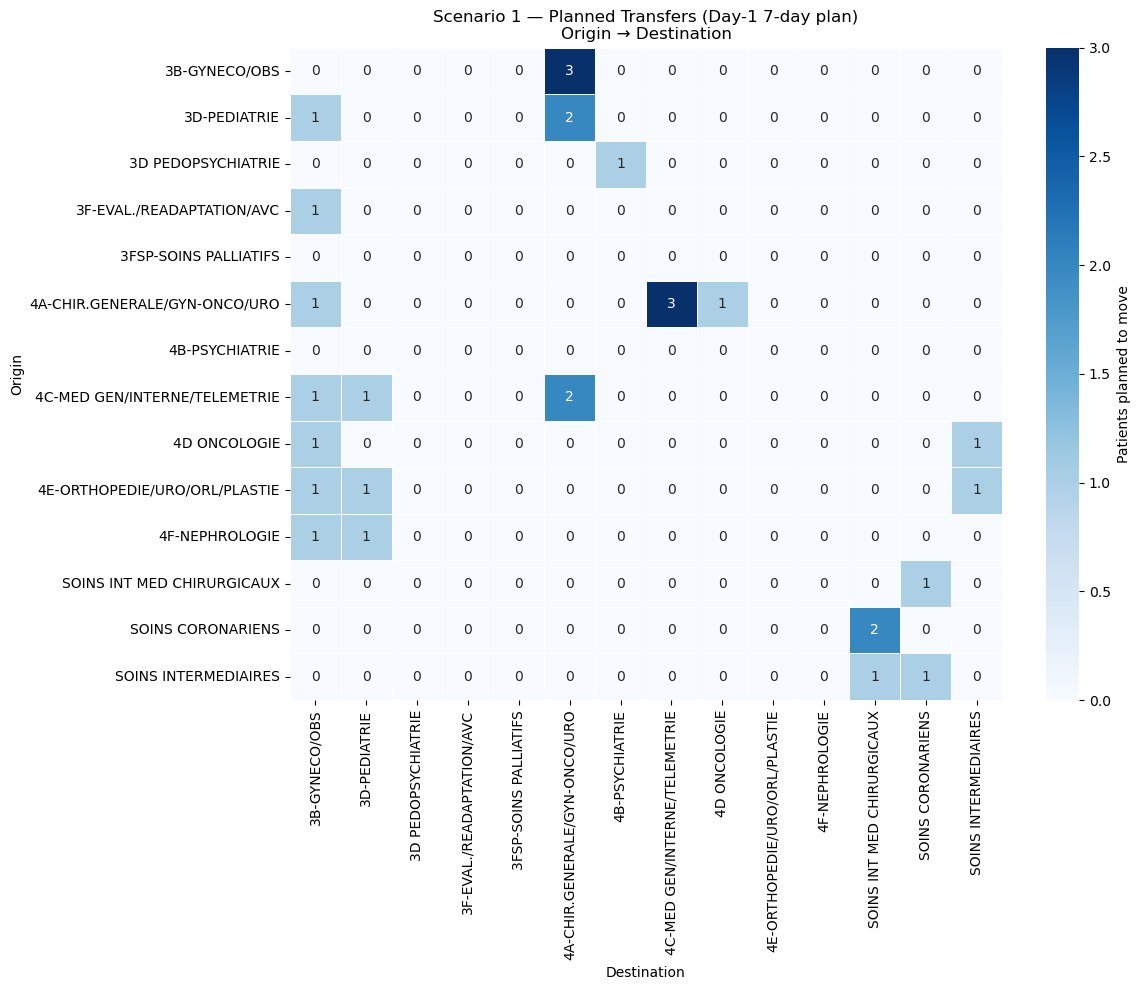

[ok] Planned transfers heatmap saved: planned_transfers_heatmap_20250706_horizon.png

Top planned transfer flows (sum over planned horizon):


,Origin,Destination,Patients
0,3B-GYNECO/OBS,4A-CHIR.GENERALE/GYN-ONCO/URO,3
6,4A-CHIR.GENERALE/GYN-ONCO/URO,4C-MED GEN/INTERNE/TELEMETRIE,3
3,3D-PEDIATRIE,4A-CHIR.GENERALE/GYN-ONCO/URO,2
18,SOINS CORONARIENS,SOINS INT MED CHIRURGICAUX,2
10,4C-MED GEN/INTERNE/TELEMETRIE,4A-CHIR.GENERALE/GYN-ONCO/URO,2
13,4E-ORTHOPEDIE/URO/ORL/PLASTIE,3B-GYNECO/OBS,1
20,SOINS INTERMEDIAIRES,SOINS CORONARIENS,1
19,SOINS INT MED CHIRURGICAUX,SOINS CORONARIENS,1
17,4F-NEPHROLOGIE,3D-PEDIATRIE,1
16,4F-NEPHROLOGIE,3B-GYNECO/OBS,1


[ok] Top planned flows saved: planned_transfers_top_flows_20250706_horizon.csv


In [3]:
# ====================== SCENARIO 1 — PLANNED TRANSFERS (Day-1 horizon) ======================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

anchor_file = f"plan_day_{ANCHOR_DATE}.xlsx"
if not os.path.exists(anchor_file):
    raise FileNotFoundError(f"Anchor workbook not found: {anchor_file}\n"
                            "Run the Day-1 model or adjust ANCHOR_DATE.")

# Build empty matrix Origin x Destination
units = UNIT_ORDER
mat_planned = pd.DataFrame(0, index=units, columns=units, dtype=int)
planned_rows = []

# Try to read the full 7-day planned transfers (preferred)
have_horizon_sheet = False
try:
    df_plan = pd.read_excel(anchor_file, sheet_name="HorizonTransfers")
    if not df_plan.empty and {"Origin","Destination","Patients"}.issubset(df_plan.columns):
        have_horizon_sheet = True
except Exception:
    pass

if have_horizon_sheet:
    # Clean up types
    df_plan = df_plan.rename(columns=str)
    df_plan["Origin"]      = df_plan["Origin"].astype(str)
    df_plan["Destination"] = df_plan["Destination"].astype(str)
    df_plan["Patients"]    = pd.to_numeric(df_plan["Patients"], errors="coerce").fillna(0).astype(int)
    # Keep only known units, positive patients, within the 7-day window (if Date column exists)
    if "Date" in df_plan.columns:
        # enforce 7-day window from ANCHOR_DATE just in case
        day0 = pd.to_datetime(ANCHOR_DATE)
        window = [(day0 + pd.Timedelta(days=i)).strftime("%Y-%m-%d") for i in range(NUM_DAYS)]
        df_plan = df_plan[df_plan["Date"].astype(str).isin(window)].copy()
    for _, r in df_plan.iterrows():
        o, d, n = r["Origin"], r["Destination"], int(r["Patients"])
        if o in units and d in units and n > 0:
            mat_planned.loc[o, d] += n
            planned_rows.append({
                "Date": r["Date"] if "Date" in df_plan.columns else ANCHOR_DATE,
                "Origin": o, "Destination": d, "Patients": n, "Type": "Planned"
            })
    print("[ok] Loaded planned 7-day transfers from HorizonTransfers.")
else:
    # Fallback: use Day-1 NewTransfers as the planned day-1 actions only
    try:
        df_day1 = pd.read_excel(anchor_file, sheet_name="NewTransfers")
        if not df_day1.empty and {"Origin","Destination","Patients"}.issubset(df_day1.columns):
            df_day1 = df_day1.rename(columns=str)
            df_day1["Origin"]      = df_day1["Origin"].astype(str)
            df_day1["Destination"] = df_day1["Destination"].astype(str)
            df_day1["Patients"]    = pd.to_numeric(df_day1["Patients"], errors="coerce").fillna(0).astype(int)
            for _, r in df_day1.iterrows():
                o, d, n = r["Origin"], r["Destination"], int(r["Patients"])
                if o in units and d in units and n > 0:
                    mat_planned.loc[o, d] += n
                    planned_rows.append({
                        "Date": ANCHOR_DATE,
                        "Origin": o, "Destination": d, "Patients": n, "Type": "Planned (Day-1 only)"
                    })
            print("[warn] HorizonTransfers sheet missing; used NewTransfers from Day-1 as fallback.")
        else:
            print("[info] No NewTransfers found in Day-1 workbook; planned transfers are empty.")
    except Exception:
        print("[info] Could not read NewTransfers from Day-1; planned transfers are empty.")

# Save aggregated matrix
planned_mat_path = f"planned_transfers_matrix_{pd.to_datetime(ANCHOR_DATE).strftime('%Y%m%d')}_horizon.csv"
mat_planned.to_csv(planned_mat_path)
print(f"[ok] Planned transfers matrix saved: {planned_mat_path}")

# Heatmap (annotated)
plt.figure(figsize=(12,10))
ax = sns.heatmap(
    mat_planned, cmap="Blues", linewidths=0.5, linecolor="white",
    annot=True, fmt="d", cbar_kws={"label": "Patients planned to move"}
)
ax.set_title("Scenario 1 — Planned Transfers (Day-1 7-day plan)\nOrigin → Destination")
ax.set_xlabel("Destination")
ax.set_ylabel("Origin")
plt.tight_layout()
planned_png = f"planned_transfers_heatmap_{pd.to_datetime(ANCHOR_DATE).strftime('%Y%m%d')}_horizon.png"
plt.savefig(planned_png, dpi=150)
plt.show()
print(f"[ok] Planned transfers heatmap saved: {planned_png}")

# Top flows table
planned_flows = pd.DataFrame(planned_rows, columns=["Date","Origin","Destination","Patients","Type"])
if planned_flows.empty:
    print("[info] No planned transfers recorded.")
else:
    top_planned = (planned_flows.groupby(["Origin","Destination"], as_index=False)["Patients"]
                   .sum()
                   .sort_values("Patients", ascending=False)
                   .head(10))
    print("\nTop planned transfer flows (sum over planned horizon):")
    display(top_planned)
    top_planned_path = f"planned_transfers_top_flows_{pd.to_datetime(ANCHOR_DATE).strftime('%Y%m%d')}_horizon.csv"
    top_planned.to_csv(top_planned_path, index=False)
    print(f"[ok] Top planned flows saved: {top_planned_path}")


[ok] Transfers matrix saved: transfers_matrix_20250706_to_20250712.csv


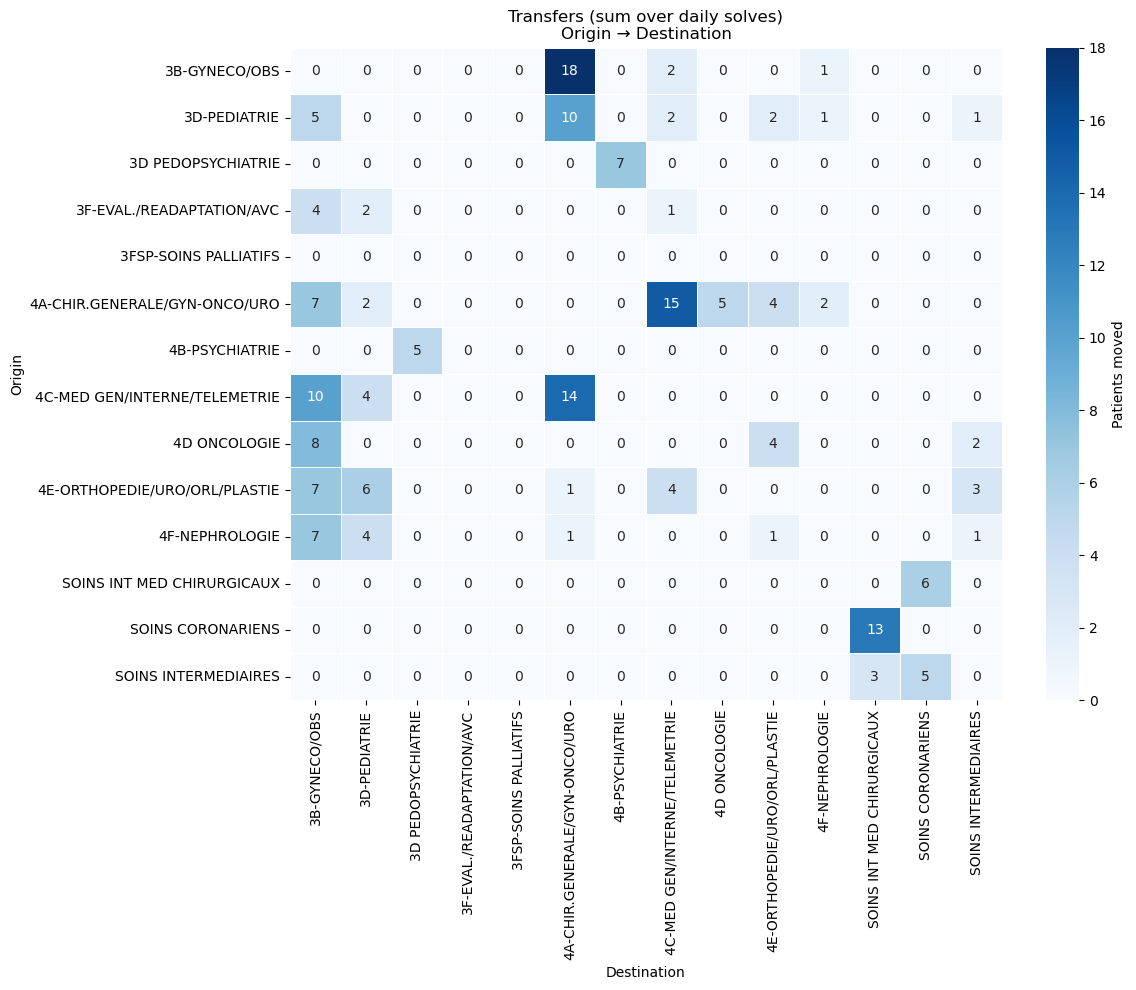

[ok] Transfers heatmap saved: transfers_heatmap_20250706_to_20250712.png

Top transfer flows (sum over period):


,Origin,Destination,Patients
0,3B-GYNECO/OBS,4A-CHIR.GENERALE/GYN-ONCO/URO,18
15,4A-CHIR.GENERALE/GYN-ONCO/URO,4C-MED GEN/INTERNE/TELEMETRIE,15
22,4C-MED GEN/INTERNE/TELEMETRIE,4A-CHIR.GENERALE/GYN-ONCO/URO,14
36,SOINS CORONARIENS,SOINS INT MED CHIRURGICAUX,13
5,3D-PEDIATRIE,4A-CHIR.GENERALE/GYN-ONCO/URO,10
20,4C-MED GEN/INTERNE/TELEMETRIE,3B-GYNECO/OBS,10
23,4D ONCOLOGIE,3B-GYNECO/OBS,8
31,4F-NEPHROLOGIE,3B-GYNECO/OBS,7
3,3D PEDOPSYCHIATRIE,4B-PSYCHIATRIE,7
13,4A-CHIR.GENERALE/GYN-ONCO/URO,3B-GYNECO/OBS,7


[ok] Top flows saved: transfers_top_flows_20250706_to_20250712.csv


In [4]:
# ====================== TRANSFERS (DAILY SOLVES- optimized) ======================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob, os

INCLUDE_BACKLOG = False  # set True to also include 'BacklogTransfers' sheet

files = sorted(glob.glob(DAILY_PATTERN))[:NUM_DAYS]
if not files:
    raise FileNotFoundError(f"No files matched pattern: {DAILY_PATTERN}")

# Build empty matrix Origin x Destination
units = UNIT_ORDER
mat = pd.DataFrame(0, index=units, columns=units, dtype=int)

flow_rows = []

for path in files:
    date_str = os.path.basename(path).split("_")[-1].split(".")[0]
    # NewTransfers
    try:
        df_t = pd.read_excel(path, sheet_name="NewTransfers")
        if not df_t.empty:
            df_t = df_t.rename(columns=str)
            df_t = df_t.rename(columns={
                "Origin":"Origin", "Destination":"Destination", "Patients":"Patients"
            })
            df_t["Patients"] = pd.to_numeric(df_t["Patients"], errors="coerce").fillna(0).astype(int)
            df_t["Origin"] = df_t["Origin"].astype(str)
            df_t["Destination"] = df_t["Destination"].astype(str)
            for _, r in df_t.iterrows():
                o, d, n = r["Origin"], r["Destination"], int(r["Patients"])
                if o in units and d in units and n>0:
                    mat.loc[o, d] += n
                    flow_rows.append({"Date": date_str, "Origin": o, "Destination": d, "Patients": n, "Type": "New"})
    except Exception:
        pass

    # BacklogTransfers (optional)
    if INCLUDE_BACKLOG:
        try:
            df_b = pd.read_excel(path, sheet_name="BacklogTransfers")
            if not df_b.empty:
                df_b = df_b.rename(columns=str)
                df_b["Patients"] = pd.to_numeric(df_b["Patients"], errors="coerce").fillna(0).astype(int)
                for _, r in df_b.iterrows():
                    o, d, n = r["Origin"], r["Destination"], int(r["Patients"])
                    if o in units and d in units and n>0:
                        mat.loc[o, d] += n
                        flow_rows.append({"Date": date_str, "Origin": o, "Destination": d, "Patients": n, "Type": "Backlog"})
        except Exception:
            pass

# Save aggregated matrix
mat_path = f"transfers_matrix_{dates[0].strftime('%Y%m%d')}_to_{dates[-1].strftime('%Y%m%d')}.csv"
mat.to_csv(mat_path)
print(f"[ok] Transfers matrix saved: {mat_path}")

# Heatmap (annotated)
plt.figure(figsize=(12,10))
ax = sns.heatmap(
    mat, cmap="Blues", linewidths=0.5, linecolor="white",
    annot=True, fmt="d", cbar_kws={"label": "Patients moved"}
)
ax.set_title("Transfers (sum over daily solves)\nOrigin → Destination")
ax.set_xlabel("Destination")
ax.set_ylabel("Origin")
plt.tight_layout()
transfer_png = f"transfers_heatmap_{dates[0].strftime('%Y%m%d')}_to_{dates[-1].strftime('%Y%m%d')}.png"
plt.savefig(transfer_png, dpi=150)
plt.show()
print(f"[ok] Transfers heatmap saved: {transfer_png}")

# Top flows table
flows = pd.DataFrame(flow_rows)
if flows.empty:
    print("[info] No transfers recorded in NewTransfers (and BacklogTransfers not included).")
else:
    top = (flows.groupby(["Origin","Destination"], as_index=False)["Patients"]
           .sum()
           .sort_values("Patients", ascending=False)
           .head(10))
    print("\nTop transfer flows (sum over period):")
    display(top)  # Jupyter: pretty table
    top_path = f"transfers_top_flows_{dates[0].strftime('%Y%m%d')}_to_{dates[-1].strftime('%Y%m%d')}.csv"
    top.to_csv(top_path, index=False)
    print(f"[ok] Top flows saved: {top_path}")


[ok] Saved used-counts CSVs:
  - bed_usage_used_counts_predicted_2025-07-06_to_2025-07-12.csv
  - bed_usage_used_counts_optimal_2025-07-06_to_2025-07-12.csv
  - bed_usage_used_counts_actual_2025-07-06_to_2025-07-12.csv


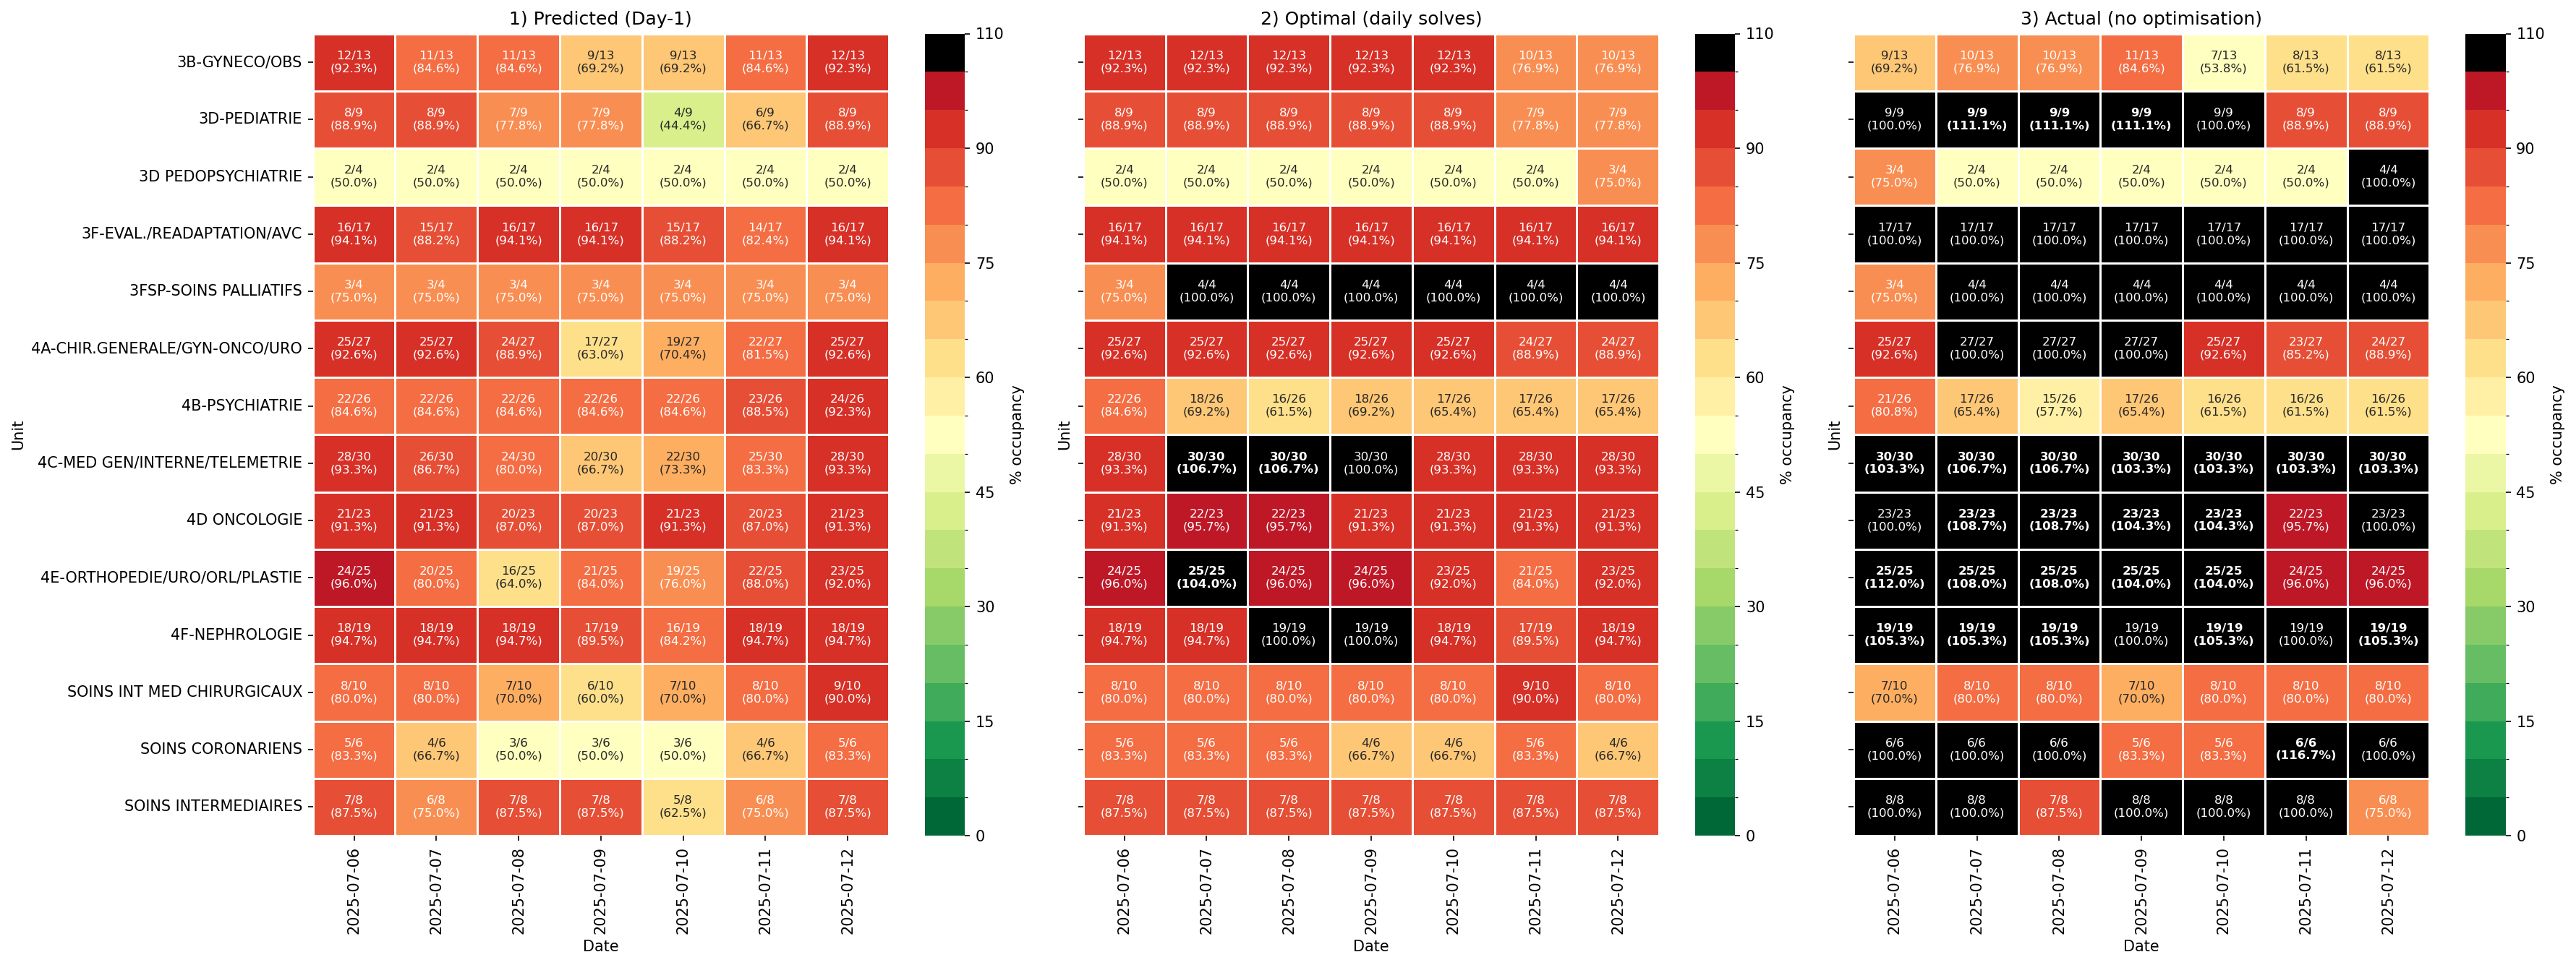

[ok] Bed-usage KPI figure saved: bed_usage_three_20250706_to_20250712.png


In [5]:
##BED USE (in relation to occupancy rate)##
# ================================================================
# KPI: Bed usage (used / open) per unit & day, colored by occupancy
# Works for the three matrices you already built:
#   - df_pred : Predicted % occupancy (Day-1 horizon)
#   - p_opt   : Optimal % occupancy (daily solves)
#   - p_act   : Actual % occupancy (raw census)
# Produces:
#   - 3 CSVs of used-bed counts (integers, capped at open beds)
#   - A 1×3 figure with labels "used/open\n(occ%)" and color = occupancy %
# Paste this block after df_pred, p_opt, p_act are created.
# ================================================================

# (1) Ensure we have staffed beds as a Series
if 'beds_series' not in globals():
    beds_series = (
        pd.read_excel(INPUTS_FILE, sheet_name=BEDS_SHEET)
          .set_index("Unit")["Beds"].astype(float)
    )

# (2) Helpers
def _ensure_cols(df, cols, units=UNIT_ORDER):
    """Order rows and limit to a common date set."""
    return ensure_unit_date_order(df, units, cols)

def _usage_labels_and_counts(occ_df: pd.DataFrame, beds_s: pd.Series):
    """
    occ_df: % occupancy (index=Unit, columns=ISO dates)
    beds_s: beds per unit (Series indexed by Unit)
    Returns:
      labels_df: 'used/open\n(xx.x%)' strings for annotation
      used_df  : integer matrix of used beds per cell (capped at open beds)
    """
    occ_df = occ_df.astype(float)
    B = beds_s.reindex(occ_df.index).astype(float)              # beds per unit
    Bmat = np.tile(B.to_numpy().reshape(-1, 1), occ_df.shape[1])

    occ = occ_df.to_numpy()                                     # % values
    used = np.minimum(np.rint(occ / 100.0 * Bmat), Bmat).astype(int)  # cap at open beds

    labels = np.empty_like(occ_df.values, dtype=object)
    for i in range(occ_df.shape[0]):
        for j in range(occ_df.shape[1]):
            u = used[i, j]
            o = int(Bmat[i, j]) if not np.isnan(Bmat[i, j]) else 0
            p = occ[i, j]
            labels[i, j] = f"{u}/{o}\n({p:.1f}%)" if not np.isnan(p) else ""

    labels_df = pd.DataFrame(labels, index=occ_df.index, columns=occ_df.columns)
    used_df   = pd.DataFrame(used,   index=occ_df.index, columns=occ_df.columns)
    return labels_df, used_df

def _annotate_contrast(ax, occ_df):
    """Make labels readable on very dark cells (>100%)."""
    vals = occ_df.to_numpy()
    if vals.size == 0:
        return
    nrows, ncols = vals.shape
    for i in range(nrows):
        for j in range(ncols):
            if pd.notna(vals[i, j]) and vals[i, j] > 100:
                idx = i * ncols + j
                if idx < len(ax.texts):
                    ax.texts[idx].set_color("white")
                    ax.texts[idx].set_fontweight("bold")

# (3) Align all three scenarios to the same NUM_DAYS worth of dates
usage_common_cols = sorted(set(df_pred.columns) & set(p_opt.columns) & set(p_act.columns))[:NUM_DAYS]
df_pred_u = _ensure_cols(df_pred, usage_common_cols)
p_opt_u   = _ensure_cols(p_opt,   usage_common_cols)
p_act_u   = _ensure_cols(p_act,   usage_common_cols)

# (4) Build labels + used counts (and save the used-count CSVs)
pred_labels, pred_used = _usage_labels_and_counts(df_pred_u, beds_series)
opt_labels,  opt_used  = _usage_labels_and_counts(p_opt_u,   beds_series)
act_labels,  act_used  = _usage_labels_and_counts(p_act_u,   beds_series)

pred_used_csv = f"bed_usage_used_counts_predicted_{usage_common_cols[0]}_to_{usage_common_cols[-1]}.csv"
opt_used_csv  = f"bed_usage_used_counts_optimal_{usage_common_cols[0]}_to_{usage_common_cols[-1]}.csv"
act_used_csv  = f"bed_usage_used_counts_actual_{usage_common_cols[0]}_to_{usage_common_cols[-1]}.csv"
pred_used.to_csv(pred_used_csv)
opt_used.to_csv(opt_used_csv)
act_used.to_csv(act_used_csv)
print(f"[ok] Saved used-counts CSVs:\n  - {pred_used_csv}\n  - {opt_used_csv}\n  - {act_used_csv}")

# (5) Plot 1×3 figure with labels "used/open\n(occ%)" and color = occupancy %
fig, axes = plt.subplots(1, 3, figsize=(24, 9), dpi=150, sharex=True, sharey=True)
norm, cmap = red_to_black_norm_cmap()  # reuse your color rules

scenarios = [
    ("1) Predicted (Day-1)", df_pred_u, pred_labels),
    ("2) Optimal (daily solves)", p_opt_u, opt_labels),
    ("3) Actual (no optimisation)", p_act_u, act_labels),
]

for ax, (title, occ_df, labels_df) in zip(axes, scenarios):
    sns.heatmap(
        occ_df, cmap=cmap, norm=norm,
        vmin=0, vmax=101,
        linewidths=.5, linecolor="white",
        cbar_kws={"label": "% occupancy"},
        annot=labels_df, fmt="", annot_kws={"size": 8},
        ax=ax
    )
    _annotate_contrast(ax, occ_df)
    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Unit")

plt.tight_layout()
usage_out = f"bed_usage_three_{usage_common_cols[0].replace('-','')}_to_{usage_common_cols[-1].replace('-','')}.png"
plt.savefig(usage_out, dpi=150, bbox_inches="tight")
plt.show()
print(f"[ok] Bed-usage KPI figure saved: {usage_out}")



[warn] No valid 'nurse_ratios' sheet found; using defaults for all units.
[ok] Saved nurses CSV: nurses_needed_predicted_day_2025-07-06_to_2025-07-12.csv
[ok] Saved nurses CSV: nurses_needed_optimal_day_2025-07-06_to_2025-07-12.csv
[ok] Saved nurses CSV: nurses_needed_actual_day_2025-07-06_to_2025-07-12.csv


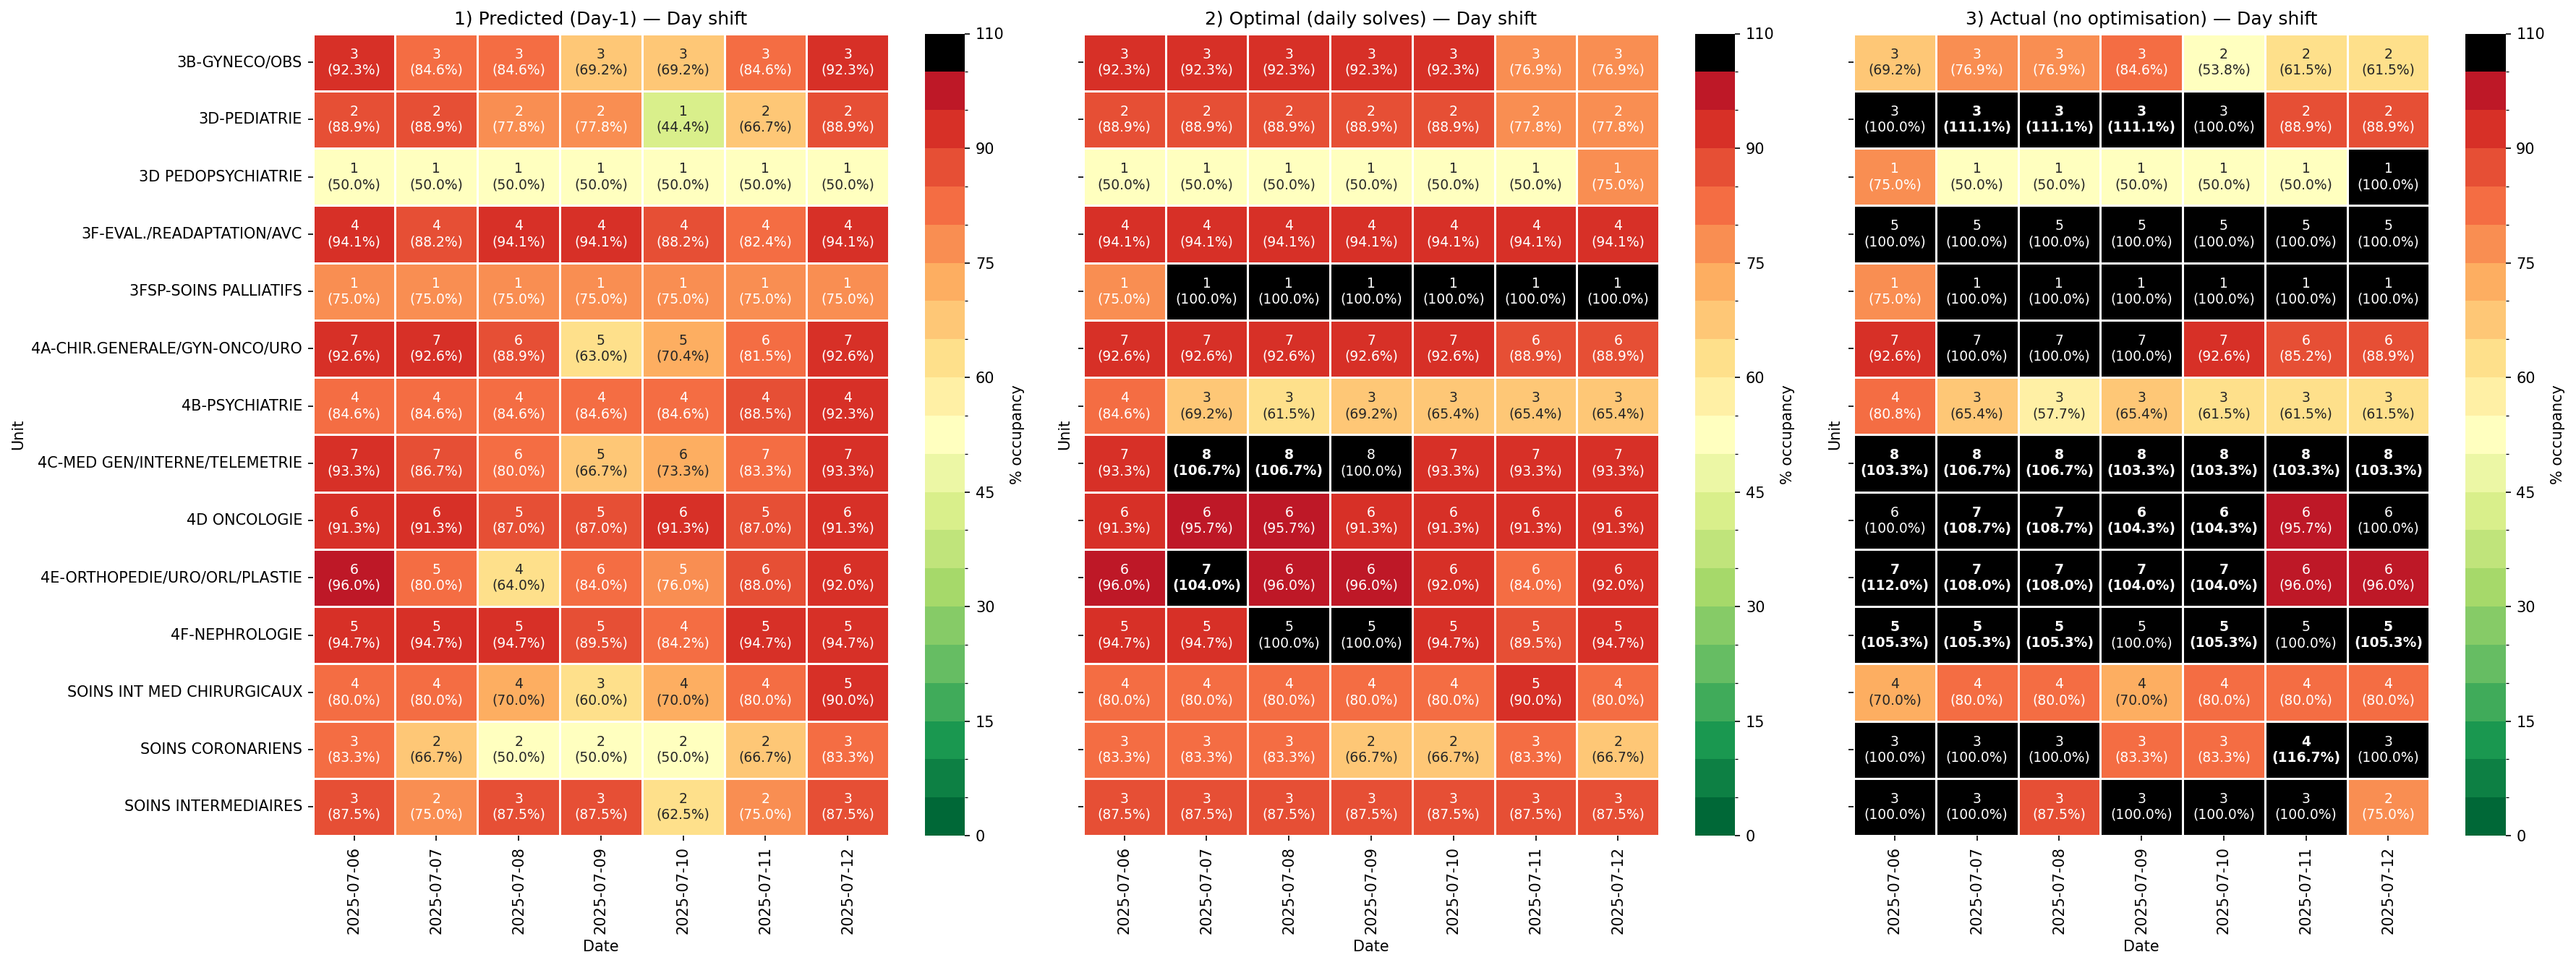

[ok] Nurse staffing panel saved: nurse_staffing_panels_20250706_to_20250712_day.png
[ok] Saved nurses CSV: nurses_needed_predicted_eve_2025-07-06_to_2025-07-12.csv
[ok] Saved nurses CSV: nurses_needed_optimal_eve_2025-07-06_to_2025-07-12.csv
[ok] Saved nurses CSV: nurses_needed_actual_eve_2025-07-06_to_2025-07-12.csv


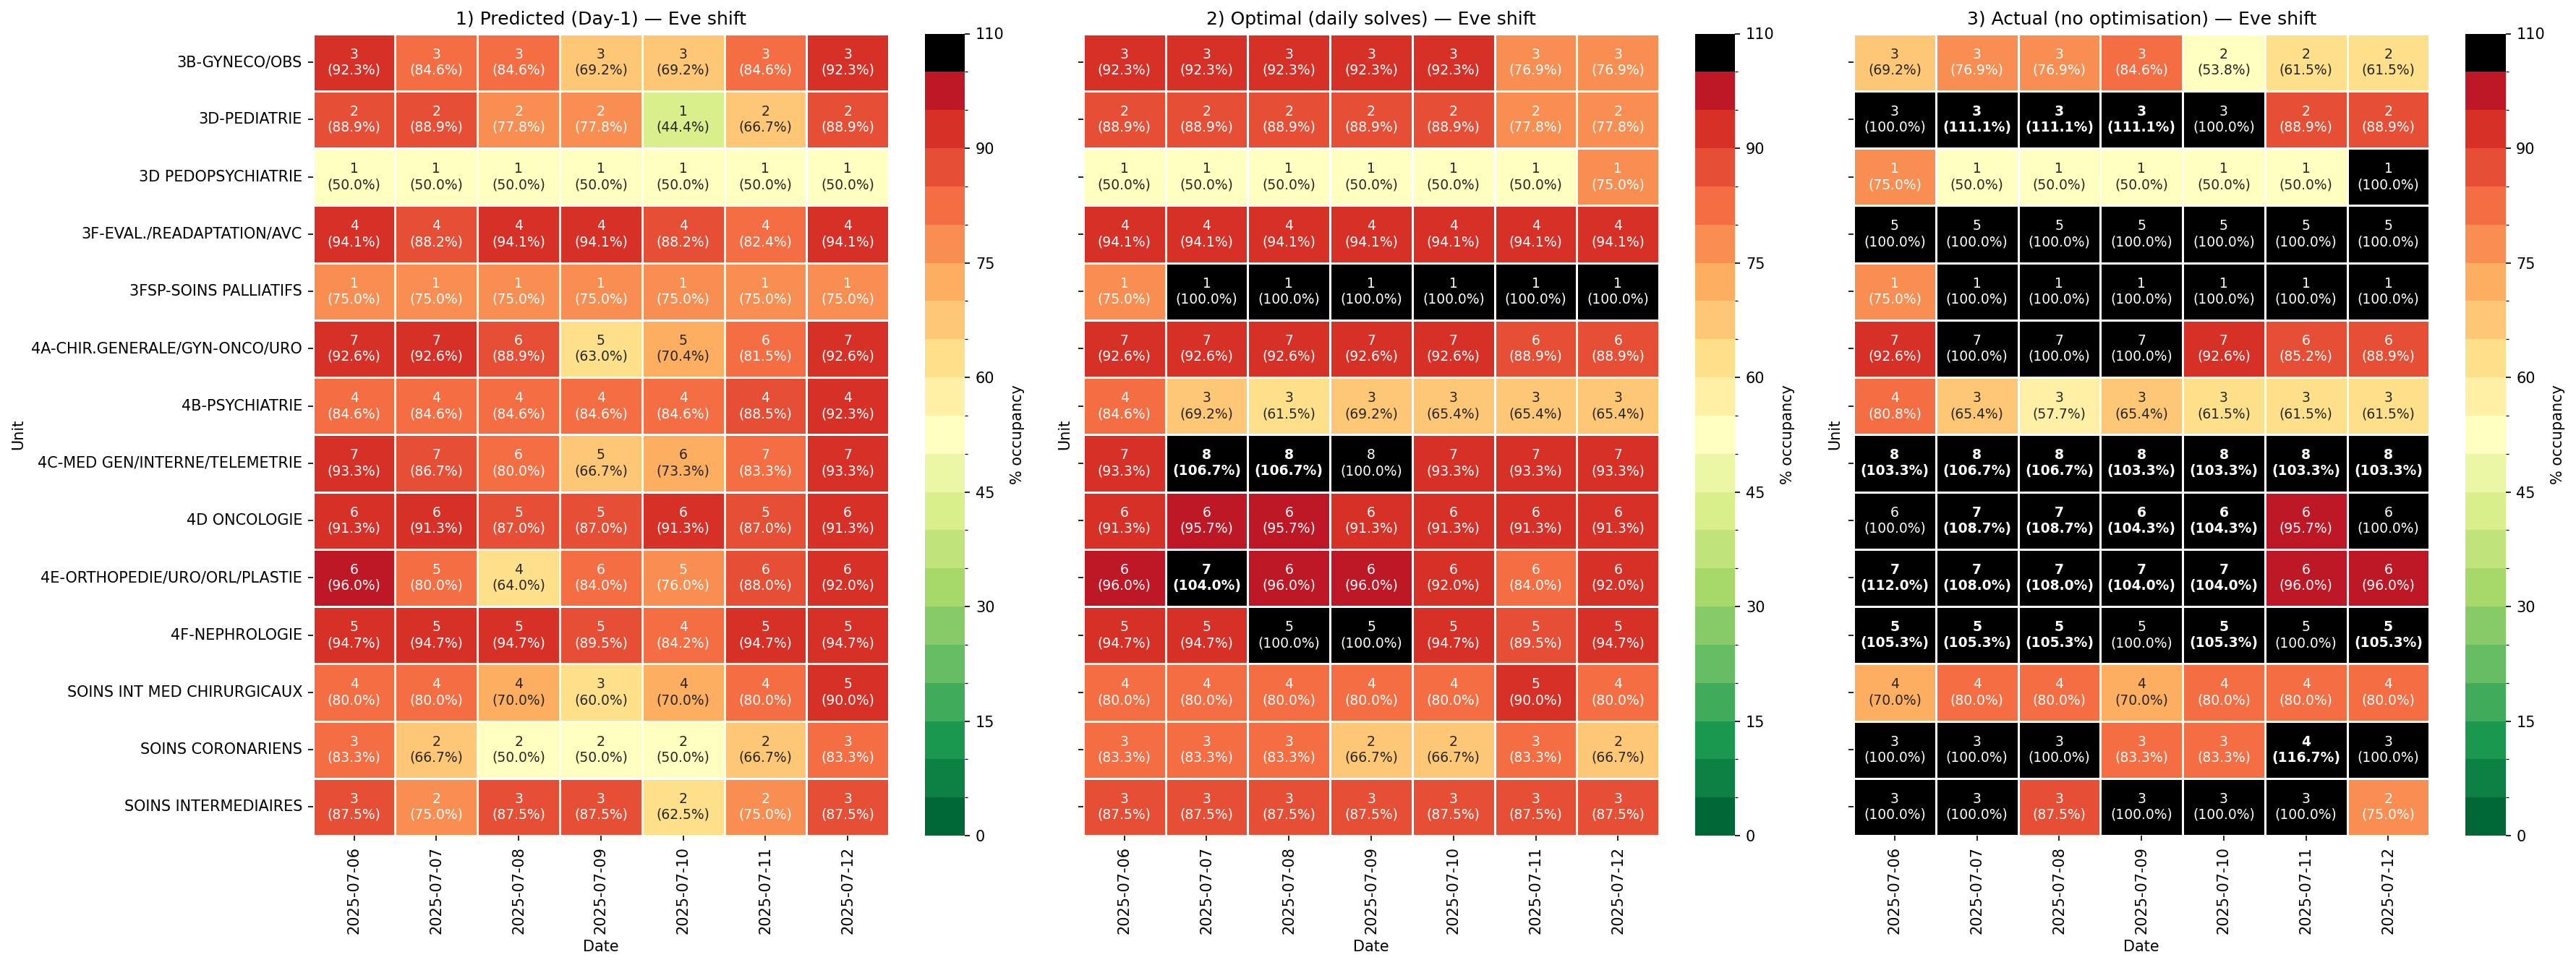

[ok] Nurse staffing panel saved: nurse_staffing_panels_20250706_to_20250712_eve.png
[ok] Saved nurses CSV: nurses_needed_predicted_night_2025-07-06_to_2025-07-12.csv
[ok] Saved nurses CSV: nurses_needed_optimal_night_2025-07-06_to_2025-07-12.csv
[ok] Saved nurses CSV: nurses_needed_actual_night_2025-07-06_to_2025-07-12.csv


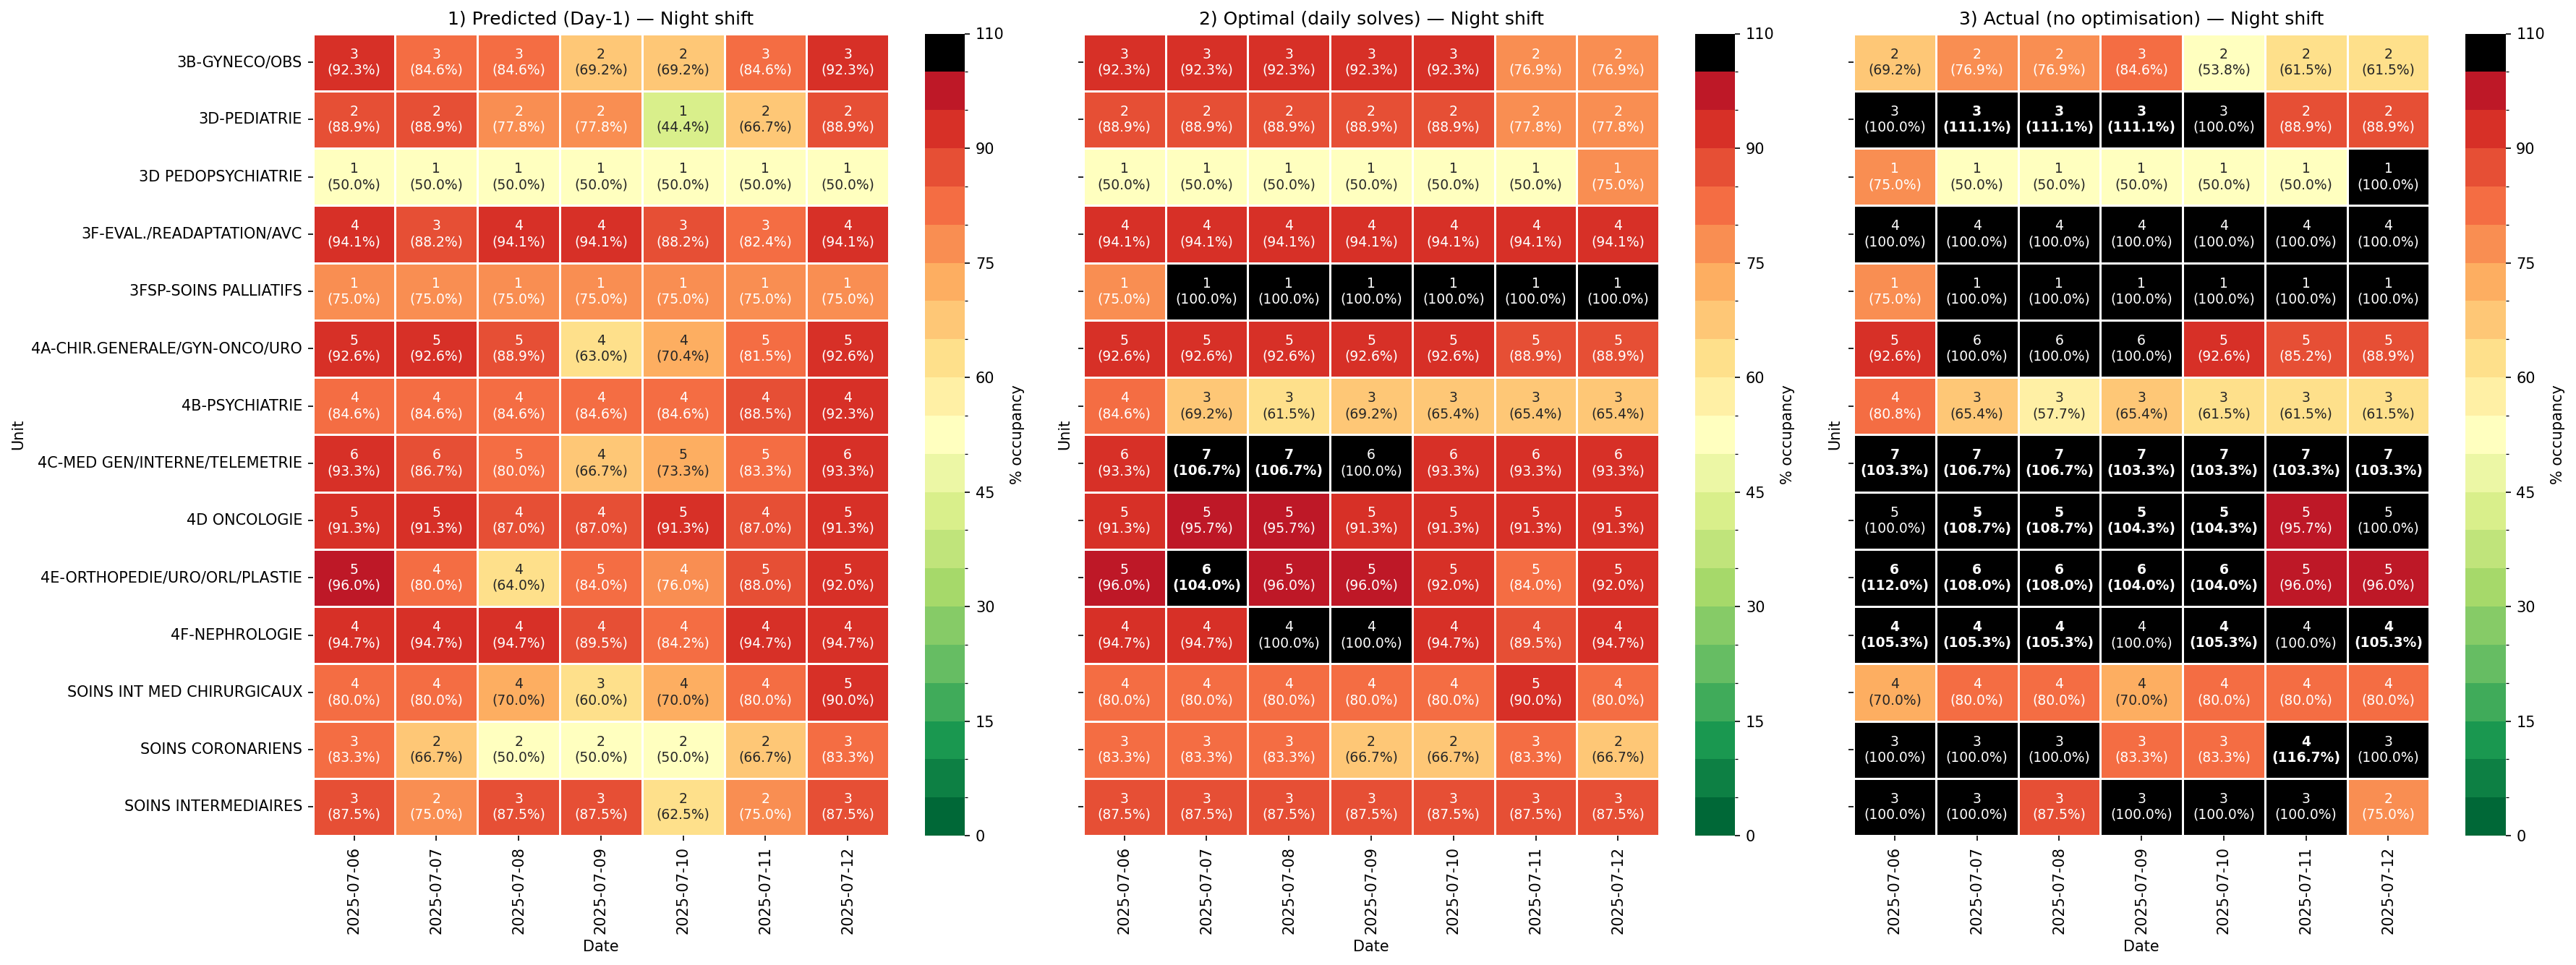

[ok] Nurse staffing panel saved: nurse_staffing_panels_20250706_to_20250712_night.png


In [6]:
##Staff needed##
# ================================================================
# KPI: Nurses required per unit & day (per shift), tied to occupancy
# Inputs expected from earlier blocks:
#   - df_pred : Predicted % occupancy (Day-1 horizon)
#   - p_opt   : Optimal % occupancy (daily solves)
#   - p_act   : Actual % occupancy (raw census)
#   - UNIT_ORDER, INPUTS_FILE, BEDS_SHEET, NUM_DAYS
# What this block does:
#   1) Load nurse staffing ratios from `INPUTS_FILE` sheet "nurse_ratios"
#      (fallback to sensible defaults by unit name if sheet missing).
#      Sheet format (any order): Unit, PPN_Day, PPN_Eve, PPN_Night
#      PPN_* means Patients Per Nurse for that shift.
#   2) Compute nurses needed per unit/day/shift for each scenario.
#   3) Save 9 CSVs (3 scenarios × 3 shifts) with integer nurse counts.
#   4) Plot 3 figures (1 per shift), each a 1×3 panel:
#         color = occupancy %, label = "Nurses\n(occ%)"
# ================================================================

# ---------- utilities ----------
def _canon(s):  # canonicalize unit names
    return str(s).strip()

def _load_beds_series():
    if 'beds_series' in globals():
        return beds_series.astype(float)
    return (
        pd.read_excel(INPUTS_FILE, sheet_name=BEDS_SHEET)
          .assign(Unit=lambda d: d['Unit'].map(_canon))
          .set_index("Unit")["Beds"].astype(float)
    )

def _default_ppn_triplet_for_unit(unit_lower: str):
    """
    Heuristic fallback: (PPN_Day, PPN_Eve, PPN_Night) = patients-per-nurse
    Tweak as you see fit; these are generic placeholders.
    """
    # ICU / Coronary / Critical
    if ("coronari" in unit_lower) or ("int " in unit_lower) or ("intens" in unit_lower):
        return (2, 2, 2)
    # Intermediate care
    if ("intermedia" in unit_lower):
        return (3, 3, 3)
    # Pediatrics
    if ("pediatr" in unit_lower):
        return (4, 4, 4)
    # Psychiatry
    if ("psychi" in unit_lower) or ("pedopsy" in unit_lower):
        return (6, 6, 6)
    # Oncology / Telemetry / Internal Med / Med-Surg / Rehab / Stroke / Palliative / Nephro
    if any(k in unit_lower for k in ["onco", "telemet", "med gen", "interne", "eval", "readapt", "avc", "palliat", "nephro"]):
        return (4, 4, 5)
    # Surgical / Ortho / Uro / ORL / Plastics / Gyn-Obs
    if any(k in unit_lower for k in ["chir", "orthoped", "uro", "orl", "plast", "gyneco", "obs"]):
        return (4, 4, 5)
    # Default med-surg-ish
    return (4, 4, 5)

def load_nurse_ratios(units: list, xlsx_path: str = INPUTS_FILE, sheet_name: str = "nurse_ratios"):
    """
    Try to load ratios from Excel. If the sheet is missing or values are NaN/0,
    fallback to defaults per unit name.
    Returns: dict {unit: {"day":ppn, "eve":ppn, "night":ppn}}
    """
    units_c = [_canon(u) for u in units]
    ratios = {}
    from_sheet = None
    try:
        df = pd.read_excel(xlsx_path, sheet_name=sheet_name)
        # Accept flexible column naming
        cols = {c.lower().strip(): c for c in df.columns}
        ucol = cols.get("unit", None)
        dcol = cols.get("ppn_day", cols.get("day", None))
        ecol = cols.get("ppn_eve", cols.get("evening", cols.get("eve", None)))
        ncol = cols.get("ppn_night", cols.get("night", None))
        if ucol and dcol and ecol and ncol:
            from_sheet = (ucol, dcol, ecol, ncol)
            for _, r in df.iterrows():
                u = _canon(r[ucol])
                if not u: 
                    continue
                d = pd.to_numeric(r[dcol], errors="coerce")
                e = pd.to_numeric(r[ecol], errors="coerce")
                n = pd.to_numeric(r[ncol], errors="coerce")
                d = None if (pd.isna(d) or d <= 0) else float(d)
                e = None if (pd.isna(e) or e <= 0) else float(e)
                n = None if (pd.isna(n) or n <= 0) else float(n)
                ratios[u] = {"day": d, "eve": e, "night": n}
    except Exception:
        pass

    # fill with defaults where missing
    out = {}
    for u in units_c:
        base = ratios.get(u, {"day": None, "eve": None, "night": None})
        d, e, n = base["day"], base["eve"], base["night"]
        if (d is None) or (e is None) or (n is None):
            dd, ee, nn = _default_ppn_triplet_for_unit(u.lower())
            d = d or dd
            e = e or ee
            n = n or nn
        out[u] = {"day": float(d), "eve": float(e), "night": float(n)}
    if from_sheet:
        print(f"[info] Nurse ratios loaded from sheet '{sheet_name}' (fallbacks applied where needed).")
    else:
        print(f"[warn] No valid '{sheet_name}' sheet found; using defaults for all units.")
    return out

def _nurses_needed_per_shift(occ_df: pd.DataFrame, beds_s: pd.Series, ratios: dict, shift: str):
    """
    occ_df: % occupancy, index=Unit, columns=ISO dates
    beds_s: beds per unit
    ratios: {unit: {"day":ppn, "eve":ppn, "night":ppn}}
    shift : "day" | "eve" | "night"
    Returns:
      nurses_df : integer nurses required per cell
      labels_df : string labels "N\n(occ%)"
    """
    occ_df = occ_df.copy()
    occ_df.index = occ_df.index.map(_canon)
    beds_s = beds_s.copy()
    beds_s.index = beds_s.index.map(_canon)

    # align to known units/dates
    units = [u for u in UNIT_ORDER if u in occ_df.index]
    cols  = [c for c in occ_df.columns]
    occ_df = occ_df.reindex(index=units, columns=cols)
    B = beds_s.reindex(units).astype(float)
    Bmat = np.tile(B.to_numpy().reshape(-1, 1), len(cols))

    occ = occ_df.astype(float).to_numpy()            # %
    headcount = np.rint(occ / 100.0 * Bmat)          # ~patients present
    ppn = np.array([ratios[u][shift] for u in units], dtype=float).reshape(-1, 1)
    nurses = np.ceil(headcount / ppn).astype(int)
    nurses_df = pd.DataFrame(nurses, index=units, columns=cols)

    labels = np.empty_like(occ, dtype=object)
    for i in range(len(units)):
        for j in range(len(cols)):
            p = occ[i, j]
            n = nurses[i, j]
            labels[i, j] = f"{n}\n({p:.1f}%)" if not np.isnan(p) else ""
    labels_df = pd.DataFrame(labels, index=units, columns=cols)
    return nurses_df, labels_df

def _plot_nurse_panels(scenario_mats, labels_mats, shift, out_prefix, norm, cmap):
    """
    scenario_mats: list of (title, occ_df)
    labels_mats  : list of labels DataFrames (same order)
    Colors == occupancy %, Text == nurses needed.
    """
    fig, axes = plt.subplots(1, 3, figsize=(24, 9), dpi=150, sharex=True, sharey=True)
    for ax, ((title, occ_df), labels_df) in zip(axes, zip(scenario_mats, labels_mats)):
        sns.heatmap(
            occ_df, cmap=cmap, norm=norm,
            vmin=0, vmax=101,
            linewidths=.5, linecolor="white",
            cbar_kws={"label": "% occupancy"},
            annot=labels_df, fmt="", annot_kws={"size": 9},
            ax=ax
        )
        # Improve contrast for >100%
        vals = occ_df.to_numpy()
        nrows, ncols = vals.shape
        for i in range(nrows):
            for j in range(ncols):
                if pd.notna(vals[i, j]) and vals[i, j] > 100:
                    idx = i * ncols + j
                    if idx < len(ax.texts):
                        ax.texts[idx].set_color("white")
                        ax.texts[idx].set_fontweight("bold")
        ax.set_title(f"{title} — {shift.capitalize()} shift")
        ax.set_xlabel("Date")
        ax.set_ylabel("Unit")
    plt.tight_layout()
    png = f"{out_prefix}_{shift}.png"
    plt.savefig(png, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[ok] Nurse staffing panel saved: {png}")

# ---------- prepare inputs ----------
beds_series = _load_beds_series()
ratios = load_nurse_ratios(UNIT_ORDER)

# Align all three scenarios to the same date set
common_cols = sorted(set(df_pred.columns) & set(p_opt.columns) & set(p_act.columns))[:NUM_DAYS]
df_pred_n = ensure_unit_date_order(df_pred, UNIT_ORDER, common_cols)
p_opt_n   = ensure_unit_date_order(p_opt,   UNIT_ORDER, common_cols)
p_act_n   = ensure_unit_date_order(p_act,   UNIT_ORDER, common_cols)

# Color scale (same as your occupancy heatmaps)
norm, cmap = red_to_black_norm_cmap()

# ---------- compute nurses per shift & save CSVs ----------
scenarios = [
    ("1) Predicted (Day-1)", df_pred_n, "predicted"),
    ("2) Optimal (daily solves)", p_opt_n, "optimal"),
    ("3) Actual (no optimisation)", p_act_n, "actual"),
]

for shift in ["day", "eve", "night"]:
    label_mats = []
    scenario_mats = []
    for title, occ_df, tag in scenarios:
        nurses_df, labels_df = _nurses_needed_per_shift(occ_df, beds_series, ratios, shift)
        # save the integer counts
        csv_path = f"nurses_needed_{tag}_{shift}_{common_cols[0]}_to_{common_cols[-1]}.csv"
        nurses_df.to_csv(csv_path)
        print(f"[ok] Saved nurses CSV: {csv_path}")

        scenario_mats.append((title, occ_df))
        label_mats.append(labels_df)

    # figure per shift (3 panels)
    _plot_nurse_panels(
        scenario_mats,
        label_mats,
        shift,
        out_prefix=f"nurse_staffing_panels_{common_cols[0].replace('-','')}_to_{common_cols[-1].replace('-','')}",
        norm=norm,
        cmap=cmap
    )
